[![](imagens/colab-badge.png){height="20px" style="height:20px;vertical-align:middle"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.pt/cap02/cap02.EPs_aluno.ipynb)
[![](imagens/github-badge.png){height="20px" style="height:20px;vertical-align:middle"}](https://github.com/fzampirolli/pdi-vc)

## 💻 **Parte Prática com Exercícios de Programação**


### 🎯 Objetivo deste Caderno {.unnumbered}

O caderno permite desenvolver, validar, organizar e testar soluções de  **Exercícios de Programação (EPs)** em ambientes interativos, como o Colab, com os mesmos casos de teste do Moodle, copiando para lá apenas na hora de registrar a nota oficial.

#### *Download* {.unnumbered}

Baixe `morph.py` e `testsuite.py` executando a célula abaixo:

In [1]:
#[py]#
#| quarto-raw: true
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup(testsuite=True)
from morph import mm
from testsuite import TestSuite


✅ Ambiente pronto. Morph: 1.1.9 | OpenCV: 5.0.0 | TestSuite: 1.1.2


In [2]:
#[cpp]#
#| quarto-raw: true
import os, urllib.request

os.makedirs("tmp/state", exist_ok=True)  # artefatos de build da trilha C++ (.cpp, binário, PNGs)

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

# O kernel é Python mesmo na trilha C++: `mm` (morph.py) é usado pelos
# simuladores, pela exibição das figuras que o binário C++ gera e pelo
# estado mm::Image entre células. cpp=True baixa também a trilha compilada
# (morph.hpp + stb_image*.h), usada no #include das células %%writefile *.cpp.
import config
config.setup(testsuite=True, cpp=True)
from morph import mm
from testsuite import TestSuite


✅ Ambiente pronto. Morph: 1.1.9 | OpenCV: 5.0.0 | TestSuite: 1.1.2


#### Executando os Testes {.unnumbered}
Para avaliar os testes, execute `TestSuite("EP04_01.extensão").run()` numa nova célula, trocando a extensão pela da linguagem usada (`.py`, `.java`, `.c`, `.cpp`, `.js` ou `.r`). O sistema baixa os casos de teste do GitHub, executa o programa e calcula a nota automaticamente.

Para testar código Python diretamente, sem salvar arquivo, use `run_code(codigo)` passando o código como *string* numa variável `codigo`:

```python
codigo = """
from morph import mm
# ... seu código aqui ...
"""
TestSuite("EP04_01").run_code(codigo)
```

### EP02_01 ☀️ Ajuste de Brilho e Contraste

Nesta atividade, o objetivo é implementar um operador de ponto para **transformação linear de intensidade**, aplicando o ajuste dinâmico de brilho e contraste em uma imagem digital.

#### 📋 Diretrizes de Implementação

O algoritmo deve seguir o fluxo de execução abaixo:

1. **Dimensões:** Ler os inteiros $L$ (linhas) e $C$ (colunas) da matriz.
2. **Parâmetros:** Ler o valor real $\alpha$ (fator de contraste) e o inteiro $\beta$ (fator de brilho).
3. **Dados:** Ler os valores inteiros da matriz original.
4. **Mapeamento:** Para cada pixel $p$, calcular o novo valor $p'$ pela equação:

$$p' = \text{clip}(\text{round}(\alpha \cdot p + \beta))$$

5. **Saída:** Exibir a matriz resultante com as dimensões $L \times C$.

#### 📌 Restrições Computacionais

* **Arredondamento (*Round*):** Aplica-se o arredondamento matemático para o inteiro mais próximo antes da conversão de tipo.
* **Saturação (*Clipping*):** Os valores devem ser confinados ao intervalo $[0, 255]$ para preservar o padrão de 8 bits:

$$\text{clip}(x) = \max(0, \min(255, x))$$

* **Simulação:** O efeito dos parâmetros $\alpha$ e $\beta$ na correção histogramática pode ser observado na @fig-02-sim-ep0201-brilho-contraste.

#### 🧠 Fundamentação Teórica

As alterações modificam o histograma da imagem para ajustar o perfil de iluminação e a distinção tonal.

| Parâmetro | Função | Impacto Visual |
| --- | --- | --- |
| **$\alpha$ (*Alpha*)** | Escalar | Modula o **Contraste**. Se $\alpha > 1$, expande o histograma; se $0 \le \alpha < 1$, comprime. |
| **$\beta$ (*Beta*)** | Aditiva | Modula o **Brilho**. Se positivo, translada o histograma para a direita; se negativo, para a esquerda. |
| **$\text{clip}$** | Limitador | Restringe a faixa dinâmica, impedindo erros de *underflow* e *overflow*. |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiro $L$.
* Linha 2: Inteiro $C$.
* Linha 3: Valores de `alpha` ($\alpha$) e `beta` ($\beta$).
* Linhas seguintes: Elementos numéricos da matriz original.

**Saída:**

* Matriz transformada estruturada em $L$ linhas e $C$ colunas.

#### 📌 Exemplos

A tabela a seguir apresenta um exemplo prático do comportamento esperado do algoritmo, destacando a atuação dos operadores de arredondamento e saturação.

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>4<br>1.5 -30<br>0 100 180 255 | 0 120 240 255 | Note o efeito de saturação no último pixel |



#### Executando os Testes {.unnumbered}

Para avaliar os testes, execute `TestSuite("EP02_01.extensão").run()` numa nova célula, trocando a extensão pela da linguagem usada (`.py`, `.java`, `.c`, `.cpp`, `.js` ou `.r`). O sistema baixa os casos de teste do GitHub, executa o programa e calcula a nota automaticamente.

In [3]:
#| label: fig-02-sim-ep0201-brilho-contraste
#| fig-cap: "Simulador EP02_01: Ajuste de Brilho e Contraste Linear (p' = αp + β)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0201-brilho-contraste" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">☀️ Simulador EP02_01: Ajuste de Brilho e Contraste Linear</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">p' = clip(α·p + β)</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste os parâmetros de contraste (α) e brilho (β) para aplicar a transformação pontual de intensidade e observe o truncamento de saturação no intervalo [0, 255].</p>

    <!-- Controles de Parâmetros (Alpha e Beta) -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;">
      
      <!-- Contraste (Alpha) -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#b9770e;">α (Contraste / Ganho)</label>
          <span id="sim_ep0201_vl_alpha" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">1.0</span>
        </div>
        <input type="range" id="sim_ep0201_sl_alpha" min="0" max="3" step="0.1" value="1" style="width:100%;cursor:pointer;">
      </div>

      <!-- Brilho (Beta) -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#2980b9;">β (Brilho / Offset)</label>
          <span id="sim_ep0201_vl_beta" style="font-family:monospace;font-size:12px;font-weight:700;color:#2980b9;">0</span>
        </div>
        <input type="range" id="sim_ep0201_sl_beta" min="-100" max="100" step="1" value="0" style="width:100%;cursor:pointer;">
      </div>

    </div>

    <!-- Comparativo Lado a Lado: Entrada vs Saída -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Entrada Original -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Entrada Original (p)</span>
        <div id="sim_ep0201_grid_orig" style="display:grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0201_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Imagem</button>
      </div>

      <!-- Resultado Transformado -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Resultado Transformado (p')</span>
        <div id="sim_ep0201_grid_new" style="display:grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0201_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar Parâmetros</button>
      </div>

    </div>

    <!-- Fórmula Aplicada Explicativa -->
    <div id="sim_ep0201_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Fórmula aplicada: <b>clip( round(1.0 · p + (0)) )</b>
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0201(root){
    if (!root || root.dataset.simEp0201Init) return;
    root.dataset.simEp0201Init = "1";

    var slAlpha = root.querySelector('#sim_ep0201_sl_alpha');
    var slBeta  = root.querySelector('#sim_ep0201_sl_beta');

    var vlAlpha = root.querySelector('#sim_ep0201_vl_alpha');
    var vlBeta  = root.querySelector('#sim_ep0201_vl_beta');

    var gridOrig = root.querySelector('#sim_ep0201_grid_orig');
    var gridNew  = root.querySelector('#sim_ep0201_grid_new');
    var debug    = root.querySelector('#sim_ep0201_debug');

    var btnNew   = root.querySelector('#sim_ep0201_btnNew');
    var btnReset = root.querySelector('#sim_ep0201_btnReset');

    var pixels = [];
    var count = 16;

    function generate() {
      pixels = Array.from({length: count}, function(){ return Math.floor(Math.random() * 256); });
    }

    function render() {
      var a = parseFloat(slAlpha.value) || 0;
      var b = parseInt(slBeta.value) || 0;

      vlAlpha.textContent = a.toFixed(1);
      vlBeta.textContent  = b;
      debug.innerHTML = 'Fórmula aplicada: <b>clip( round(' + a.toFixed(1) + ' · p + (' + b + ')) )</b>';

      gridOrig.innerHTML = '';
      gridNew.innerHTML  = '';

      pixels.forEach(function(p) {
        // Célula Original
        var cellO = document.createElement('div');
        var fgColorO = p > 128 ? '#000000' : '#ffffff';
        cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;background:rgb(' + p + ',' + p + ',' + p + ');color:' + fgColorO + ';';
        cellO.textContent = p;
        gridOrig.appendChild(cellO);

        // Célula Transformada com Truncamento (clip)
        var calc = Math.round(a * p + b);
        var res = Math.max(0, Math.min(255, calc));
        var fgColorN = res > 128 ? '#000000' : '#ffffff';

        var cellN = document.createElement('div');
        cellN.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + res + ',' + res + ',' + res + ');color:' + fgColorN + ';';
        cellN.textContent = res;
        gridNew.appendChild(cellN);
      });
    }

    slAlpha.addEventListener('input', render);
    slBeta.addEventListener('input', render);

    btnNew.addEventListener('click', function() {
      generate();
      render();
    });

    btnReset.addEventListener('click', function() {
      slAlpha.value = 1;
      slBeta.value  = 0;
      render();
    });

    generate();
    render();
  }

  function tryInitSimEP0201(){
    var root = document.getElementById('sim-ep0201-brilho-contraste');
    if (root) initSimEP0201(root); else setTimeout(tryInitSimEP0201, 200);
  }
  tryInitSimEP0201();
})();
</script>
</div>
""")

In [4]:
%%writefile EP02_01.py
# sua solução

Overwriting EP02_01.py


In [5]:
TestSuite("EP02_01.py").run()


### EP02_02 🔬 Subamostragem Espacial

Nesta atividade, você deve implementar a redução da resolução espacial de uma imagem através do processo de subamostragem.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia um valor inteiro **$f$** ($f \ge 1$), que representa o fator de amostragem.
* Leia os valores inteiros da matriz original.
* A nova imagem deve ser construída selecionando o pixel da posição $(f \cdot i, f \cdot j)$ da imagem original.
* Imprima a matriz resultante com as novas dimensões.
* Ver na @fig-02-sim-ep0202-subamostragem uma simulação deste EP.

📌 **Importante**:

* **Dimensões Finais:** A imagem amostrada terá dimensões $\lceil L/f \rceil \times \lceil C/f \rceil$. No contexto de programação, isso equivale ao tamanho resultante de um fatiamento (slicing) com passo $f$.
* **Implementação:** Não utilize funções prontas de bibliotecas de processamento de imagens (como OpenCV ou PIL) para o redimensionamento. Implemente a lógica de seleção de pixels manualmente ou via fatiamento de matrizes.
* **Aliasing:** Note que este processo pode causar o efeito de *aliasing* (serrilhamento), onde detalhes finos são perdidos ou padrões indesejados aparecem.

#### 🧠 Discretização do Espaço

A subamostragem reduz a resolução espacial de uma imagem, selecionando apenas um pixel a cada $f$ pixels em cada direção. É o processo inverso da interpolação:

| Parâmetro | Função | Efeito |
| --- | --- | --- |
| **Fator $f$** | Salto de amostragem | Define o intervalo de seleção. Um fator $2$ reduz a largura e altura pela metade. |
| **Resolução** | Densidade de pixels | Diminui a quantidade total de informação espacial da imagem. |
| **Aliasing** | Efeito colateral | Surgimento de padrões em escada ou blocos devido à perda de detalhes finos. |

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o fator `f`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz reduzida com as dimensões correspondentes ao fatiamento por `f`.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>4<br>2<br>10 20 30 40<br>50 60 70 80 | 10 30 | O fator 2 seleciona os pixels (0,0) e (0,2) da primeira linha. A segunda linha é ignorada. |

In [6]:
#| label: fig-02-sim-ep0202-subamostragem
#| fig-cap: "Simulador EP02_02: Subamostragem Espacial (Redução de Resolução por Salto f)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0202-subamostragem" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🔽 Simulador EP02_02: Subamostragem Espacial de Imagem</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">p'(i, j) = p(i·f, j·f)</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste o fator de subamostragem (f) para observar a redução na dimensão espacial da matriz e a amostragem por salto dos pixels superiores esquerdos de cada bloco f × f.</p>

    <!-- Controle do Fator de Subamostragem f -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;">
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
        <label style="font-size:11px;font-weight:700;color:#b9770e;">Fator de Subamostragem (f)</label>
        <span id="sim_ep0202_vl_fator" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">1</span>
      </div>
      <input type="range" id="sim_ep0202_sl_fator" min="1" max="4" step="1" value="1" style="width:100%;cursor:pointer;">
      <div style="margin-top:6px;font-size:10px;color:#8a8371;text-align:center;font-family:monospace;">
        f = 1 → Resolução Original (4×4) &nbsp;|&nbsp; f = 2 → Metade (2×2) &nbsp;|&nbsp; f = 3 ou 4 → Amostra Única (1×1)
      </div>
    </div>

    <!-- Comparativo Lado a Lado: Original vs Amostrada -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Matriz Original (4x4) -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Original (4×4)</span>
        <div id="sim_ep0202_grid_orig" style="display:grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0202_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Matriz</button>
      </div>

      <!-- Matriz Subamostrada -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Subamostrada (Tamanho Variável)</span>
        <div id="sim_ep0202_grid_sub" style="display:grid;gap:4px;justify-content:center;user-select:none;min-height:180px;align-content:center;"></div>
        <button id="sim_ep0202_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar (f = 1)</button>
      </div>

    </div>

    <!-- Mensagem Explicativa Dinâmica -->
    <div id="sim_ep0202_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Fator f = 1 → mantém todos os pixels originais (4×4)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0202(root){
    if (!root || root.dataset.simEp0202Init) return;
    root.dataset.simEp0202Init = "1";

    var slFator  = root.querySelector('#sim_ep0202_sl_fator');
    var vlFator  = root.querySelector('#sim_ep0202_vl_fator');
    var gridOrig = root.querySelector('#sim_ep0202_grid_orig');
    var gridSub  = root.querySelector('#sim_ep0202_grid_sub');
    var debugDiv = root.querySelector('#sim_ep0202_debug');

    var btnNew   = root.querySelector('#sim_ep0202_btnNew');
    var btnReset = root.querySelector('#sim_ep0202_btnReset');

    var pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });

    function render() {
      var f = parseInt(slFator.value) || 1;
      vlFator.textContent = f;

      // Renderiza Grade Original (4x4)
      gridOrig.innerHTML = '';
      for (var i = 0; i < 16; i++) {
        var val = pixels[i];
        var cell = document.createElement('div');
        var fgColorO = val > 128 ? '#000000' : '#ffffff';
        cell.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;background:rgb(' + val + ',' + val + ',' + val + ');color:' + fgColorO + ';';
        cell.textContent = val;
        gridOrig.appendChild(cell);
      }

      // Calcula dimensões subamostradas
      var newRows = Math.floor(4 / f);
      var newCols = Math.floor(4 / f);

      if (newRows === 0 || newCols === 0) {
        gridSub.innerHTML = '<div style="padding:20px;color:#8a8371;font-size:11px;font-family:monospace;">Tamanho inválido</div>';
        debugDiv.innerHTML = 'Fator f = ' + f + ' → resolução menor que 1×1';
        return;
      }

      gridSub.style.gridTemplateColumns = 'repeat(' + newCols + ', 42px)';
      gridSub.innerHTML = '';

      for (var r = 0; r < newRows; r++) {
        for (var c = 0; c < newCols; c++) {
          var origRow = r * f;
          var origCol = c * f;
          var idx = origRow * 4 + origCol;
          var v = pixels[idx];

          var cellS = document.createElement('div');
          var fgColorS = v > 128 ? '#000000' : '#ffffff';
          cellS.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + v + ',' + v + ',' + v + ');color:' + fgColorS + ';';
          cellS.textContent = v;
          gridSub.appendChild(cellS);
        }
      }

      debugDiv.innerHTML = 'Fator f = ' + f + ' → novo tamanho: <b>' + newRows + '×' + newCols + '</b> (amostra do canto superior esquerdo do bloco ' + f + '×' + f + ')';
    }

    slFator.addEventListener('input', render);

    btnNew.addEventListener('click', function() {
      pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
      render();
    });

    btnReset.addEventListener('click', function() {
      slFator.value = '1';
      render();
    });

    render();
  }

  function tryInitSimEP0202(){
    var root = document.getElementById('sim-ep0202-subamostragem');
    if (root) initSimEP0202(root); else setTimeout(tryInitSimEP0202, 200);
  }
  tryInitSimEP0202();
})();
</script>
</div>
""")

In [7]:
%%writefile EP02_02.py
# Código Python

Overwriting EP02_02.py


In [8]:
TestSuite("EP02_02.py").run()

### EP02_03 🎨 Quantização de Níveis de Cinza

Nesta atividade, você deve implementar a quantização uniforme de uma imagem, reduzindo a quantidade de níveis de intensidade de cinza originais para uma nova escala baseada em um número menor de bits.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um inteiro **$k$** ($1 \le k \le 8$), representando o novo número de bits da imagem.
* Calcule o número de níveis ($N = 2^k$) e o tamanho do intervalo (passo).
* Para cada pixel $p$, calcule o novo valor $p'$ mapeando-o para o índice do nível discretizado correspondente (variando de $0$ a $2^k-1$).
* Imprima a matriz resultante com os mesmos valores de dimensões originais.
* Ver na @fig-02-sim-ep0203-quantizacao uma simulação deste EP.

📌 **Importante**:

* **Posterização:** Ao reduzir drasticamente os níveis (ex: $k=2$), você notará que degradês suaves se transformam em faixas abruptas de cor devido à perda de resolução de amplitude.
* **Cálculo do Passo:** O intervalo entre cada nível é definido por $passo = 256 / 2^k$.
* **Mapeamento:** O método de quantização uniforme por truncamento que mapeia o pixel para o índice do seu respectivo nível discretizado é dado por:

$$p' = \left\lfloor \frac{p}{passo} \right\rfloor$$

Em termos de implementação (como em Python), isso equivale à divisão inteira: `p' = p // passo`.

#### 🧠 Discretização da Amplitude

Enquanto a subamostragem lida com a resolução espacial, a quantização foca na precisão da cor (amplitude). Reduzir os bits significa simplificar a informação cromática:

| Parâmetro | Função | Efeito |
| --- | --- | --- |
| **Bits ($k$)** | Profundidade de cor | Define quantos tons diferentes a imagem pode ter ($2^k$). |
| **Passo** | Intervalo de tom | Espaçamento entre os níveis de cinza permitidos. |
| **Posterização** | Fenômeno visual | Transformação de variações contínuas em blocos de cor sólida. |

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o número de bits `k`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com os índices dos níveis quantizados, mantendo o tamanho original $L \times C$.

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>4<br>2<br>0 80 170 255 | 0 1 2 3 | Com $k=2$, temos $2^2=4$ níveis discretos disponíveis ($0,1,2,3$). O passo é $256/4=64$. Aplicando a divisão inteira por elemento: $0 // 64 = 0$, $80 // 64 = 1$, $170 // 64 = 2$, $255 // 64 = 3$. |
| 1<br>5<br>1<br>10 50 120 200 250 | 0 0 0 1 1 | Com $k=1$, temos $2^1=2$ níveis ($0$ e $1$). Passo $=256/2=128$. Pixels menores que $128$ resultam em $0$, e pixels maiores ou iguais a $128$ resultam em $1$. |

In [9]:
#| label: fig-02-sim-ep0203-quantizacao
#| fig-cap: "Simulador EP02_03: Quantização e Profundidade de Bits (Redução do Número de Níveis de Cinza)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0203-quantizacao" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🎚️ Simulador EP02_03: Quantização e Profundidade de Bits</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">q = round(p · (L − 1) / 255)</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste o número de bits de saída (b) para observar o mapeamento dos 256 níveis contínuos de cinza para L = 2ᵇ níveis discretos de quantização.</p>

    <!-- Controle do Número de Bits -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;">
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
        <label style="font-size:11px;font-weight:700;color:#b9770e;">Número de Bits na Saída (b)</label>
        <span id="sim_ep0203_vl_bits" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">8</span>
      </div>
      <input type="range" id="sim_ep0203_sl_bits" min="1" max="8" step="1" value="8" style="width:100%;cursor:pointer;">
      <div style="margin-top:6px;font-size:10px;color:#8a8371;text-align:center;font-family:monospace;">
        Níveis discretos (L = 2ᵇ): <span id="sim_ep0203_vl_levels" style="font-weight:700;color:#26241d;">256</span> &nbsp;|&nbsp;
        Valores exibidos: <b>0</b> a <b id="sim_ep0203_vl_max">255</b>
      </div>
    </div>

    <!-- Comparativo Lado a Lado: Original vs Quantizada -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Entrada Original (8 bits -> 0 ... 255) -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Original (8 bits → 0…255)</span>
        <div id="sim_ep0203_grid_orig" style="display:grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0203_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Matriz</button>
      </div>

      <!-- Saída Quantizada -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Quantizada (Faixa <span id="sim_ep0203_range_label">0…255</span>)</span>
        <div id="sim_ep0203_grid_quant" style="display:grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0203_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar (8 bits)</button>
      </div>

    </div>

    <!-- Mensagem Explicativa Dinâmica -->
    <div id="sim_ep0203_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Bits de saída = 8 → 256 níveis (valores originais preservados)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0203(root){
    if (!root || root.dataset.simEp0203Init) return;
    root.dataset.simEp0203Init = "1";

    var slBits     = root.querySelector('#sim_ep0203_sl_bits');
    var vlBits     = root.querySelector('#sim_ep0203_vl_bits');
    var vlLevels   = root.querySelector('#sim_ep0203_vl_levels');
    var vlMax      = root.querySelector('#sim_ep0203_vl_max');
    var gridOrig   = root.querySelector('#sim_ep0203_grid_orig');
    var gridQuant  = root.querySelector('#sim_ep0203_grid_quant');
    var debugDiv   = root.querySelector('#sim_ep0203_debug');
    var rangeLabel = root.querySelector('#sim_ep0203_range_label');

    var btnNew   = root.querySelector('#sim_ep0203_btnNew');
    var btnReset = root.querySelector('#sim_ep0203_btnReset');

    var pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });

    function quantize(p, bits) {
      if (bits >= 8) return p;
      var levels = Math.pow(2, bits);
      var idx = Math.round(p * (levels - 1) / 255);
      return Math.min(levels - 1, Math.max(0, idx));
    }

    function render() {
      var bits = parseInt(slBits.value) || 8;
      var levels = Math.pow(2, bits);
      var maxVal = levels - 1;

      vlBits.textContent = bits;
      vlLevels.textContent = levels;
      vlMax.textContent = maxVal;
      rangeLabel.textContent = '0…' + maxVal;

      gridOrig.innerHTML = '';
      gridQuant.innerHTML = '';

      for (var i = 0; i < 16; i++) {
        var p = pixels[i];

        // Célula Original (8 bits)
        var cellO = document.createElement('div');
        var fgColorO = p > 128 ? '#000000' : '#ffffff';
        cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;background:rgb(' + p + ',' + p + ',' + p + ');color:' + fgColorO + ';';
        cellO.textContent = p;
        gridOrig.appendChild(cellO);

        // Célula Quantizada
        var nivel = quantize(p, bits);
        var tom = Math.round(nivel * 255 / maxVal);
        var fgColorQ = tom > 128 ? '#000000' : '#ffffff';

        var cellQ = document.createElement('div');
        cellQ.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + tom + ',' + tom + ',' + tom + ');color:' + fgColorQ + ';';
        cellQ.textContent = nivel;
        gridQuant.appendChild(cellQ);
      }

      debugDiv.innerHTML = 'Bits de saída = <b>' + bits + '</b> → <b>' + levels + '</b> níveis discretos (faixa exibida: 0…' + maxVal + ')';
    }

    slBits.addEventListener('input', render);

    btnNew.addEventListener('click', function() {
      pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
      render();
    });

    btnReset.addEventListener('click', function() {
      slBits.value = '8';
      render();
    });

    render();
  }

  function tryInitSimEP0203(){
    var root = document.getElementById('sim-ep0203-quantizacao');
    if (root) initSimEP0203(root); else setTimeout(tryInitSimEP0203, 200);
  }
  tryInitSimEP0203();
})();
</script>
</div>
""")

In [10]:
%%writefile EP02_03.py
# Código Python

Overwriting EP02_03.py


In [11]:
TestSuite("EP02_03.py").run()

### EP02_04 📐 Transformada de Distância em Imagem Binária

Dada uma imagem binária onde pixels de valor **1** representam o *objeto* e pixels **0** representam o *fundo*, a distância de um pixel de fundo recebe a **menor distância ao pixel de objeto mais próximo**. Pixels de objeto recebem distância **0**. Para simplificar, considere que a imagem tem **apenas um único objeto com um pixel de valor 1**.

**Problema:** Leia uma imagem binária $L \times C$ e uma métrica, e calcule essa distância simplificada aplicando uma das três fórmulas:

$$d_{\text{Euclidiana}} = \sqrt{(\Delta r)^2 + (\Delta c)^2}$$

$$d_{\text{City-block}} = |\Delta r| + |\Delta c|$$

$$d_{\text{Chessboard}} = \max(|\Delta r|,\; |\Delta c|)$$

onde $\Delta r$ é a diferença de linhas e $\Delta c$ a diferença de colunas entre dois pixels.

#### 🖼️ Por que isso importa? - Aplicações da DT

A Transformada de Distância (DT) aparece em dezenas de pipelines de visão computacional:

| Métrica       | Complexidade         | Aplicação típica                         |
|:--------------|:---------------------|:-----------------------------------------|
| Euclidiana    | 🔴 $O(n^2)$ ingênuo   | Esqueletização, matching de formas       |
| City-block    | 🟡 $O(n)$ com 2 passes | Morfologia, dilatação/erosão        |
| Chessboard    | 🟢 $O(n)$ com 2 passes | Morfologia, dilatação/erosão             |

#### 📌 Requisitos Técnicos

* **Entrada:** * Primeira linha: $L$ e $C$ (inteiros).  
    * Segunda linha: nome da métrica (`euclidean`, `cityblock` ou `chessboard`).  
    * Em seguida, a matriz binária $L \times C$ (valores 0 ou 1).

* **Pixels de objeto (1):** distância $= 0$ (ou $0.00$ para euclidiana).  
* **Pixels de fundo (0):** distância ao único pixel de objeto na imagem.  
* **Arredondamento (euclidiana):** imprimir com **2 casas decimais** (formato `:.2f`). City-block e Chessboard produzem inteiros — imprimir sem decimais.  
* **Saída:** valores separados por espaço, uma linha por linha da matriz.
* Ver na @fig-02-sim-ep0204-distancia uma simulação deste EP.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 4<br>4<br>chessboard<br>0 0 0 0<br>0 0 0 0<br>0 0 1 0<br>0 0 0 0 | 2 2 2 2<br>2 1 1 1<br>2 1 0 1<br>2 1 1 1 | A distância Chessboard é $\max(\|dx\|, \|dy\|)$. O único pixel objeto é $(2,2)=0$; os demais armazenam sua distância mínima até ele. |


#### 📌 Observações finais

* Como a imagem tem **apenas um objeto de um pixel**, a distância de cada pixel de fundo é simplesmente a distância desse pixel ao único ponto objeto.
* A implementação pode usar força bruta (percorrer todos os pixels da imagem e calcular a distância diretamente), pois $L$ e $C$ são pequenos nos casos de teste.
* Este problema é um aquecimento para a Transformada de Distância geral, que será trabalhada em capítulos posteriores com múltiplos objetos e algoritmos otimizados.

In [12]:
#| label: fig-02-sim-ep0204-distancia
#| fig-cap: "Simulador EP02_04: Transformada de Distância em Imagem Binária (Chessboard, City-block e Euclidiana)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0204-distancia" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">📐 Simulador EP02_04: Transformada de Distância Interativa</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Métricas: L₁, L₂ e L_∞</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Clique sobre as células da <b>Imagem Binária</b> para alternar os pixels do objeto (1) e observe o mapa de menor distância calculado na matriz resultante.</p>

    <!-- Barra de Seletor de Métrica e Ações -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:10px 14px;margin-bottom:16px;display:flex;gap:12px;align-items:center;flex-wrap:wrap;justify-content:space-between;">
      
      <div style="display:flex;align-items:center;gap:12px;flex-wrap:wrap;">
        <span style="font-size:11px;font-weight:700;color:#26241d;">Métrica:</span>
        <label style="font-size:11px;font-weight:600;color:#5e5a4a;cursor:pointer;display:inline-flex;align-items:center;gap:4px;">
          <input type="radio" name="sim_ep0204_metric" value="chessboard" checked style="cursor:pointer;"> Chessboard (L_∞)
        </label>
        <label style="font-size:11px;font-weight:600;color:#5e5a4a;cursor:pointer;display:inline-flex;align-items:center;gap:4px;">
          <input type="radio" name="sim_ep0204_metric" value="cityblock" style="cursor:pointer;"> City-block (L₁)
        </label>
        <label style="font-size:11px;font-weight:600;color:#5e5a4a;cursor:pointer;display:inline-flex;align-items:center;gap:4px;">
          <input type="radio" name="sim_ep0204_metric" value="euclidean" style="cursor:pointer;"> Euclidiana (L₂)
        </label>
      </div>

      <div style="display:flex;gap:6px;">
        <button id="sim_ep0204_btnClear" style="padding:5px 10px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:8px;white-space:nowrap;transition:all 0.15s ease;">🗑 Limpar</button>
        <button id="sim_ep0204_btnExample" style="padding:5px 10px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:8px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">📋 Exemplo (2,2)</button>
      </div>

    </div>

    <!-- Comparativo Lado a Lado: Entrada Binária vs Transformada -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Entrada Binária -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Imagem Binária (Clique para Editar)</span>
        <div id="sim_ep0204_grid_input" style="display:inline-grid;gap:3px;border:1px solid #e4dcc8;padding:6px;border-radius:8px;background:#ffffff;user-select:none;"></div>
      </div>

      <!-- Transformada de Distância -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Transformada de Distância</span>
        <div id="sim_ep0204_grid_output" style="display:inline-grid;gap:3px;border:1px solid #e4dcc8;padding:6px;border-radius:8px;background:#ffffff;user-select:none;"></div>
      </div>

    </div>

    <!-- Painel de Informação Explicativo -->
    <div id="sim_ep0204_info" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Grade 5×5 · 1 pixel(s) de objeto · Métrica: Chessboard (inteiro)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0204(root){
    if (!root || root.dataset.simEp0204Init) return;
    root.dataset.simEp0204Init = "1";

    var ROWS = 5, COLS = 5;
    var binary = Array.from({ length: ROWS }, function(){ return Array(COLS).fill(0); });

    // Estado inicial: objeto centralizado no ponto (2, 2)
    binary[2][2] = 1;

    var gI = root.querySelector('#sim_ep0204_grid_input');
    var gO = root.querySelector('#sim_ep0204_grid_output');
    var infoDiv = root.querySelector('#sim_ep0204_info');

    var btnClear   = root.querySelector('#sim_ep0204_btnClear');
    var btnExample = root.querySelector('#sim_ep0204_btnExample');

    function getMetric() {
      var selected = root.querySelector('input[name="sim_ep0204_metric"]:checked');
      return selected ? selected.value : 'chessboard';
    }

    function computeDT(bin, metric) {
      var L = bin.length, C = bin[0].length;
      var dt = Array.from({ length: L }, function(){ return Array(C).fill(0); });

      for (var i = 0; i < L; i++) {
        for (var j = 0; j < C; j++) {
          if (bin[i][j] === 1) {
            dt[i][j] = 0;
            continue;
          }
          var minD = Infinity;
          for (var oi = 0; oi < L; oi++) {
            for (var oj = 0; oj < C; oj++) {
              if (bin[oi][oj] !== 1) continue;
              var dr = Math.abs(i - oi), dc = Math.abs(j - oj);
              var d = 0;
              if (metric === 'euclidean') d = Math.sqrt(dr * dr + dc * dc);
              else if (metric === 'cityblock') d = dr + dc;
              else d = Math.max(dr, dc);

              if (d < minD) minD = d;
            }
          }
          dt[i][j] = minD === Infinity ? -1 : minD;
        }
      }
      return dt;
    }

    function cellColor(val, isObj, maxVal) {
      if (isObj) return { bg: '#26241d', text: '#7ee7c6' };
      if (val < 0) return { bg: '#fafaf7', text: '#8a8371' };
      
      var t = maxVal > 0 ? val / maxVal : 0;
      var r = 255;
      var g = Math.round(255 - t * 160);
      var b = Math.round(255 - t * 180);
      return {
        bg: 'rgb(' + r + ',' + g + ',' + b + ')',
        text: t > 0.55 ? '#78281f' : '#26241d'
      };
    }

    function formatVal(val, metric) {
      if (val === 0) return '0';
      if (val < 0) return '—';
      return metric === 'euclidean' ? val.toFixed(2) : String(val);
    }

    function render() {
      var metric = getMetric();
      var dt = computeDT(binary, metric);

      var allVals = [];
      for (var r = 0; r < ROWS; r++) {
        for (var c = 0; c < COLS; c++) {
          if (dt[r][c] > 0) allVals.push(dt[r][c]);
        }
      }

      var maxVal = allVals.length ? Math.max.apply(null, allVals) : 1;
      var hasObj = binary.some(function(row){ return row.some(function(v){ return v === 1; }); });

      // Renderiza Imagem Binária (Input)
      gI.style.gridTemplateColumns = 'repeat(' + COLS + ', 42px)';
      gI.innerHTML = '';
      for (var i = 0; i < ROWS; i++) {
        for (var j = 0; j < COLS; j++) {
          (function(rowIdx, colIdx){
            var isObj = binary[rowIdx][colIdx] === 1;
            var cell = document.createElement('div');
            cell.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:12px;font-weight:700;font-family:monospace;border-radius:6px;cursor:pointer;box-sizing:border-box;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;';
            cell.style.background = isObj ? '#26241d' : '#ffffff';
            cell.style.color = isObj ? '#7ee7c6' : '#8a8371';
            cell.textContent = isObj ? '1' : '0';

            cell.addEventListener('click', function() {
              binary[rowIdx][colIdx] = binary[rowIdx][colIdx] === 1 ? 0 : 1;
              render();
            });

            gI.appendChild(cell);
          })(i, j);
        }
      }

      // Renderiza Transformada de Distância (Output)
      gO.style.gridTemplateColumns = 'repeat(' + COLS + ', 42px)';
      gO.innerHTML = '';
      for (var r2 = 0; r2 < ROWS; r2++) {
        for (var c2 = 0; c2 < COLS; c2++) {
          var isObjOut = binary[r2][c2] === 1;
          var colors = cellColor(dt[r2][c2], isObjOut, maxVal);
          var cellO = document.createElement('div');
          cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10.5px;font-weight:700;font-family:monospace;border-radius:6px;box-sizing:border-box;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;';
          cellO.style.background = hasObj ? colors.bg : '#fafaf7';
          cellO.style.color = hasObj ? colors.text : '#8a8371';
          cellO.textContent = hasObj ? formatVal(dt[r2][c2], metric) : '—';
          gO.appendChild(cellO);
        }
      }

      var metricLabel = {
        euclidean: 'Euclidiana (L₂ - 2 decimais)',
        cityblock: 'City-block (L₁ - inteiro)',
        chessboard: 'Chessboard (L_∞ - inteiro)'
      };

      var objCount = binary.reduce(function(acc, row){
        return acc + row.filter(function(v){ return v === 1; }).length;
      }, 0);

      infoDiv.innerHTML = 'Grade ' + ROWS + '×' + COLS + ' · <b>' + objCount + '</b> pixel(s) de objeto · Métrica: <b>' + metricLabel[metric] + '</b>';
    }

    var radios = root.querySelectorAll('input[name="sim_ep0204_metric"]');
    radios.forEach(function(r) {
      r.addEventListener('change', render);
    });

    btnClear.addEventListener('click', function() {
      binary = Array.from({ length: ROWS }, function(){ return Array(COLS).fill(0); });
      render();
    });

    btnExample.addEventListener('click', function() {
      binary = Array.from({ length: ROWS }, function(){ return Array(COLS).fill(0); });
      binary[2][2] = 1;
      render();
    });

    render();
  }

  function tryInitSimEP0204(){
    var root = document.getElementById('sim-ep0204-distancia');
    if (root) initSimEP0204(root); else setTimeout(tryInitSimEP0204, 200);
  }
  tryInitSimEP0204();
})();
</script>
</div>
""")

In [13]:
%%writefile EP02_04.py
# Código Python

Overwriting EP02_04.py


In [14]:
TestSuite("EP02_04.py").run()


### EP02_05 ➡️ Translação de Imagem

Nesta atividade, você deve implementar o deslocamento espacial de uma imagem. A translação move cada pixel da imagem original para uma nova posição com base em um vetor de deslocamento.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia dois inteiros **$t_x$** (deslocamento horizontal) e **$t_y$** (deslocamento vertical).
* Leia os valores inteiros da matriz original.
* Calcule a nova posição $(x', y')$ para cada pixel $(x, y)$ original.
* Imprima a matriz resultante com as mesmas dimensões da original.
* Ver na @fig-02-sim-ep0205-translacao uma simulação deste EP.

📌 **Importante**:

* **Preenchimento:** Pixels que "entram" na imagem devido ao deslocamento e não possuem correspondente na original devem ser preenchidos com **0** (preto).
* **Descarte:** Pixels que, após a translação, ficarem fora dos limites da matriz ($0 \dots L-1$ ou $0 \dots C-1$) devem ser ignorados.
* **Coordenadas:** Considere $x$ como o índice da linha e $y$ como o índice da coluna.

#### 🧠 Deslocamento Espacial

Transladar uma imagem significa mover todos os seus pontos por uma distância fixa em direções especificadas. Matematicamente, usando coordenadas homogêneas, a operação é descrita como:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Que resulta nas equações simples:

* $x' = x + t_x$
* $y' = y + t_y$

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os inteiros `tx` e `ty`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz resultante com as mesmas dimensões $L \times C$ após o deslocamento.

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>1 1<br>10 20<br>30 40 | 0 0<br>0 10 | **Deslocamento ($t_x=1, t_y=1$):** Cada pixel move uma posição para a direita (horizontal) e uma para baixo (vertical). O pixel $(0,0)=10$ vai para o destino $(1,1)$ (canto inferior direito). As posições vazias são preenchidas com $0$. |
| 3<br>3<br>-1 0<br>1 2 3<br>4 5 6<br>7 8 9 | 2 3 0<br>5 6 0<br>8 9 0 | **Deslocamento ($t_x=-1, t_y=0$):** Cada pixel move uma posição para a esquerda (horizontal). A primeira coluna original (`1`, `4`, `7`) é descartada, as demais colunas movem-se para a esquerda, e a última coluna resultante é preenchida com zeros ($0$). |

In [15]:
#| label: fig-02-sim-ep0205-translacao
#| fig-cap: "Simulador EP02_05: Translação Geométrica de Imagem (Deslocamento tx e ty com Preenchimento de Borda)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0205-translacao" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">📍 Simulador EP02_05: Translação Geométrica 2D</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">p'(i, j) = p(i − ty, j − tx)</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste os deslocamentos horizontal (tx) e vertical (ty) para observar o mapeamento reverso de coordenadas e o preenchimento com zero (preto) para pixels fora dos limites da imagem original.</p>

    <!-- Controles de Deslocamento tx e ty -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;">

      <!-- Horizontal tx -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#b9770e;">tx (Horizontal → Colunas)</label>
          <span id="sim_ep0205_vl_tx" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">0</span>
        </div>
        <input type="range" id="sim_ep0205_sl_tx" min="-3" max="3" step="1" value="0" style="width:100%;cursor:pointer;">
      </div>

      <!-- Vertical ty -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#2980b9;">ty (Vertical ↓ Linhas)</label>
          <span id="sim_ep0205_vl_ty" style="font-family:monospace;font-size:12px;font-weight:700;color:#2980b9;">0</span>
        </div>
        <input type="range" id="sim_ep0205_sl_ty" min="-3" max="3" step="1" value="0" style="width:100%;cursor:pointer;">
      </div>

    </div>

    <!-- Comparativo Lado a Lado: Entrada vs Transladada -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">

      <!-- Entrada Original (4x4) -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Original (4×4)</span>
        <div id="sim_ep0205_grid_orig" style="display:inline-grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;border:1px solid #e4dcc8;padding:6px;border-radius:8px;background:#ffffff;user-select:none;"></div>
        <br>
        <button id="sim_ep0205_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Matriz</button>
      </div>

      <!-- Matriz Transladada -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Transladada (tx, ty)</span>
        <div id="sim_ep0205_grid_trans" style="display:inline-grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;border:1px solid #e4dcc8;padding:6px;border-radius:8px;background:#ffffff;user-select:none;"></div>
        <br>
        <button id="sim_ep0205_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar (tx=0, ty=0)</button>
      </div>

    </div>

    <!-- Mensagem Explicativa Dinâmica -->
    <div id="sim_ep0205_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      tx = 0, ty = 0 → nenhum deslocamento (imagem original preservada)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0205(root){
    if (!root || root.dataset.simEp0205Init) return;
    root.dataset.simEp0205Init = "1";

    var pixels = [142, 85, 210, 45, 99, 188, 32, 220, 15, 175, 90, 112, 204, 60, 130, 240];

    var slTx      = root.querySelector('#sim_ep0205_sl_tx');
    var slTy      = root.querySelector('#sim_ep0205_sl_ty');
    var vlTx      = root.querySelector('#sim_ep0205_vl_tx');
    var vlTy      = root.querySelector('#sim_ep0205_vl_ty');
    var gridOrig  = root.querySelector('#sim_ep0205_grid_orig');
    var gridTrans = root.querySelector('#sim_ep0205_grid_trans');
    var debugDiv  = root.querySelector('#sim_ep0205_debug');
    var btnNew    = root.querySelector('#sim_ep0205_btnNew');
    var btnReset  = root.querySelector('#sim_ep0205_btnReset');

    function render() {
      var tx = parseInt(slTx.value) || 0;
      var ty = parseInt(slTy.value) || 0;

      vlTx.textContent = tx;
      vlTy.textContent = ty;

      // Grade Original (4x4)
      gridOrig.innerHTML = '';
      for (var k = 0; k < 16; k++) {
        var val = pixels[k];
        var cellO = document.createElement('div');
        var fgColorO = val > 128 ? '#000000' : '#ffffff';
        cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;box-sizing:border-box;background:rgb(' + val + ',' + val + ',' + val + ');color:' + fgColorO + ';';
        cellO.textContent = val;
        gridOrig.appendChild(cellO);
      }

      // Grade Transladada (4x4)
      gridTrans.innerHTML = '';
      for (var i = 0; i < 4; i++) {
        for (var j = 0; j < 4; j++) {
          var srcRow = i - ty;
          var srcCol = j - tx;
          var v = 0;

          if (srcRow >= 0 && srcRow < 4 && srcCol >= 0 && srcCol < 4) {
            v = pixels[srcRow * 4 + srcCol];
          }

          var cellT = document.createElement('div');
          var fgColorT = v > 128 ? '#000000' : '#ffffff';
          cellT.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;box-sizing:border-box;transition:all 0.15s ease;background:rgb(' + v + ',' + v + ',' + v + ');color:' + fgColorT + ';';
          cellT.textContent = v;
          gridTrans.appendChild(cellT);
        }
      }

      var tySign = ty >= 0 ? ' − ' + ty : ' + ' + Math.abs(ty);
      var txSign = tx >= 0 ? ' − ' + tx : ' + ' + Math.abs(tx);
      debugDiv.innerHTML = 'tx = ' + tx + ' (colunas), ty = ' + ty + ' (linhas) &nbsp;|&nbsp; <b>Fórmula: p\\'[i, j] = p[i' + tySign + ', j' + txSign + ']</b> (fora dos limites → 0)';
    }

    btnNew.addEventListener('click', function() {
      pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
      render();
    });

    btnReset.addEventListener('click', function() {
      slTx.value = '0';
      slTy.value = '0';
      render();
    });

    slTx.addEventListener('input', render);
    slTy.addEventListener('input', render);

    render();
  }

  function tryInitSimEP0205(){
    var root = document.getElementById('sim-ep0205-translacao');
    if (root) initSimEP0205(root); else setTimeout(tryInitSimEP0205, 200);
  }
  tryInitSimEP0205();
})();
</script>
""")

In [16]:
%%writefile EP02_05.py
# Código Python

Overwriting EP02_05.py


In [17]:
TestSuite("EP02_05.py").run()


### EP02_06 🔄 Rotação de Imagem

Nesta atividade, você deve implementar a rotação de uma imagem em torno do seu centro geométrico. Esta operação requer o mapeamento de coordenadas e o uso de técnicas de interpolação para determinar os novos valores dos pixels.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um valor real **$\theta$** (ângulo em graus) e uma *string* representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Realize a rotação em torno do centro da imagem $(L/2, C/2)$.
* Imprima a matriz resultante com as mesmas dimensões da original.
* Ver na @fig-02-sim-ep0206-rotacao uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para evitar "buracos" na imagem final, percorra cada pixel $(x', y')$ da imagem de destino e calcule sua posição correspondente $(x, y)$ na imagem original usando a matriz de rotação inversa.
* **Interpolação:**
* `nearest`: Atribui o valor do pixel mais próximo da coordenada calculada.
* `bilinear`: Calcula uma média ponderada baseada nos 4 vizinhos mais próximos.


* **Bordas:** Pixels cuja origem $(x, y)$ caia fora dos limites da imagem original devem ser preenchidos com **0**.

#### 🧠 Transformação por Ângulo

A rotação de um ponto $(x, y)$ em relação à origem por um ângulo $\theta$ é dada pela matriz de transformação. Para rotacionar em torno de um centro $(x_c, y_c)$, primeiro transladamos o centro para a origem, rotacionamos e transladamos de volta:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta & x_c \\ \sin\theta & \cos\theta & y_c \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x-x_c \\ y-y_c \\ 1 \end{bmatrix}$$

> **Dica:** Use o mapeamento inverso para garantir que todos os pixels da imagem de saída sejam preenchidos corretamente.

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o ângulo `theta` (em graus) e o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz rotacionada com `L` linhas e `C` colunas.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>90 nearest<br>1 2<br>3 4 | 3 1<br>4 2 | Rotação de 90° horário: a coluna 0 vira a linha 0 (de baixo para cima). $(0,0)=1→(1,0)$, $(1,0)=3→(0,0)$, $(0,1)=2→(1,1)$, $(1,1)=4→(0,1)$. |
| 3<br>3<br>45 bilinear<br>0 0 0<br>0 255 0<br>0 0 0 | 0 180 0<br>180 255 180<br>0 180 0 | Rotação de 45°: o pixel central permanece $255$; os vizinhos diretos recebem valor interpolado $\approx 180$ por bilinear; os cantos permanecem $0$. |


In [18]:
#| label: fig-02-sim-ep0206-rotacao
#| fig-cap: "Simulador EP02_06: Rotação de Imagem em Torno da Origem por Ângulo θ"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0206-rotacao" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🔄 Simulador EP02_06: Rotação Geométrica 2D</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">x' = x·cosθ − y·sinθ | y' = x·sinθ + y·cosθ</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste o ângulo de rotação (θ) via slider ou atalhos rápidos para observar a transformação trigonométrica das coordenadas em torno do centro da imagem.</p>

    <!-- Painel de Controles de Ângulo -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;">
      
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
        <label style="font-size:11px;font-weight:700;color:#b9770e;">Ângulo de Rotação (θ em graus)</label>
        <span id="sim_ep0206_vl_ang" style="font-family:monospace;font-size:13px;font-weight:700;color:#b9770e;">0°</span>
      </div>

      <input type="range" id="sim_ep0206_sl_ang" min="0" max="360" step="1" value="0" style="width:100%;cursor:pointer;">

      <!-- Botões de Atalho para Ângulos Notáveis -->
      <div style="margin-top:10px;display:flex;gap:6px;justify-content:center;flex-wrap:wrap;">
        <button id="sim_ep0206_btn_0" style="padding:4px 10px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:6px;transition:all 0.15s ease;">0°</button>
        <button id="sim_ep0206_btn_90" style="padding:4px 10px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:6px;transition:all 0.15s ease;">90°</button>
        <button id="sim_ep0206_btn_180" style="padding:4px 10px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:6px;transition:all 0.15s ease;">180°</button>
        <button id="sim_ep0206_btn_270" style="padding:4px 10px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:6px;transition:all 0.15s ease;">270°</button>
        <button id="sim_ep0206_btn_reset" style="padding:4px 10px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:6px;font-family:monospace;transition:all 0.15s ease;">↩ Resetar (0°)</button>
      </div>

    </div>

    <!-- Canvas da Rotação -->
    <div style="text-align:center;margin-bottom:14px;">
      <div style="display:inline-block;background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
        <canvas id="sim_ep0206_canvas" width="300" height="300" style="border-radius:8px;border:1px solid #e4dcc8;background:#ffffff;display:block;margin:0 auto;"></canvas>
        <p style="font-size:9.5px;color:#8a8371;margin-top:8px;margin-bottom:0;font-weight:500;">
          ● Quadrado verde com marcador laranja (canto superior direito) – rotação em torno do centro.
        </p>
      </div>
    </div>

    <!-- Painel de Informação Explicativo -->
    <div id="sim_ep0206_info" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      θ = 0° → cos = 1.000, sin = 0.000 → Matriz Identidade
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0206(root){
    if (!root || root.dataset.simEp0206Init) return;
    root.dataset.simEp0206Init = "1";

    var canvas   = root.querySelector('#sim_ep0206_canvas');
    var ctx      = canvas.getContext('2d');
    var slAng    = root.querySelector('#sim_ep0206_sl_ang');
    var vlAng    = root.querySelector('#sim_ep0206_vl_ang');
    var infoDiv  = root.querySelector('#sim_ep0206_info');

    var btn0     = root.querySelector('#sim_ep0206_btn_0');
    var btn90    = root.querySelector('#sim_ep0206_btn_90');
    var btn180   = root.querySelector('#sim_ep0206_btn_180');
    var btn270   = root.querySelector('#sim_ep0206_btn_270');
    var btnReset = root.querySelector('#sim_ep0206_btn_reset');

    var w = 300, h = 300;
    var cx = w / 2, cy = h / 2;

    var size = 70;
    var half = size / 2;

    var squarePoints = [
      { x: -half, y: -half },
      { x:  half, y: -half },
      { x:  half, y:  half },
      { x: -half, y:  half }
    ];

    var markerRel = { x: half, y: -half };

    function rotatePoint(px, py, angRad) {
      var cos = Math.cos(angRad);
      var sin = Math.sin(angRad);
      return {
        x: px * cos - py * sin,
        y: px * sin + py * cos
      };
    }

    function draw() {
      var angDeg = parseInt(slAng.value) || 0;
      vlAng.textContent = angDeg + "°";

      var angRad = angDeg * Math.PI / 180;
      var cosVal = Math.cos(angRad);
      var sinVal = Math.sin(angRad);

      infoDiv.innerHTML = 'θ = <b>' + angDeg + '°</b> → cos = ' + cosVal.toFixed(3) + ', sin = ' + sinVal.toFixed(3) + ' &nbsp;|&nbsp; <b>Matriz R(θ): [[' + cosVal.toFixed(3) + ', ' + (-sinVal).toFixed(3) + '], [' + sinVal.toFixed(3) + ', ' + cosVal.toFixed(3) + ']]</b>';

      ctx.clearRect(0, 0, w, h);

      ctx.save();

      // Linhas da grade suave
      ctx.strokeStyle = "#e4dcc8";
      ctx.lineWidth = 0.6;
      for (var i = 0; i <= 4; i++) {
        var pos = i * (w / 4);
        ctx.beginPath();
        ctx.moveTo(pos, 0); ctx.lineTo(pos, h);
        ctx.stroke();
        ctx.beginPath();
        ctx.moveTo(0, pos); ctx.lineTo(w, pos);
        ctx.stroke();
      }

      // Eixos Centrais
      ctx.beginPath();
      ctx.moveTo(cx, 0); ctx.lineTo(cx, h);
      ctx.moveTo(0, cy); ctx.lineTo(w, cy);
      ctx.strokeStyle = "#8a8371";
      ctx.lineWidth = 1.0;
      ctx.stroke();

      // Quadrado Rotacionado
      var rotatedPoints = squarePoints.map(function(p){
        return rotatePoint(p.x, p.y, angRad);
      });

      var canvasPoints = rotatedPoints.map(function(p){
        return { x: cx + p.x, y: cy + p.y };
      });

      ctx.beginPath();
      ctx.moveTo(canvasPoints[0].x, canvasPoints[0].y);
      for (var k = 1; k < canvasPoints.length; k++) {
        ctx.lineTo(canvasPoints[k].x, canvasPoints[k].y);
      }
      ctx.closePath();

      ctx.fillStyle = "rgba(39, 174, 96, 0.65)";
      ctx.fill();
      ctx.strokeStyle = "#27ae60";
      ctx.lineWidth = 2.0;
      ctx.stroke();

      // Marcador de Orientação no Canto (Laranja)
      var rotatedMarker = rotatePoint(markerRel.x, markerRel.y, angRad);
      var mX = cx + rotatedMarker.x;
      var mY = cy + rotatedMarker.y;

      ctx.beginPath();
      ctx.arc(mX, mY, 7, 0, 2 * Math.PI);
      ctx.fillStyle = "#b9770e";
      ctx.fill();
      ctx.strokeStyle = "#26241d";
      ctx.lineWidth = 1.2;
      ctx.stroke();

      // Ponto Central (Origem da Rotação)
      ctx.beginPath();
      ctx.arc(cx, cy, 3, 0, 2 * Math.PI);
      ctx.fillStyle = "#c0392b";
      ctx.fill();

      ctx.restore();

      // Texto de Ângulo
      ctx.font = "bold 11px monospace";
      ctx.fillStyle = "#26241d";
      ctx.fillText(angDeg + "°", cx + 8, cy - 8);
    }

    slAng.addEventListener('input', draw);

    btn0.addEventListener('click', function() { slAng.value = 0; draw(); });
    btn90.addEventListener('click', function() { slAng.value = 90; draw(); });
    btn180.addEventListener('click', function() { slAng.value = 180; draw(); });
    btn270.addEventListener('click', function() { slAng.value = 270; draw(); });
    btnReset.addEventListener('click', function() { slAng.value = 0; draw(); });

    draw();
  }

  function tryInitSimEP0206(){
    var root = document.getElementById('sim-ep0206-rotacao');
    if (root) initSimEP0206(root); else setTimeout(tryInitSimEP0206, 200);
  }
  tryInitSimEP0206();
})();
</script>
</div>
""")

In [19]:
%%writefile EP02_06.py
# Código Python

Overwriting EP02_06.py


In [20]:
TestSuite("EP02_06.py").run()


### EP02_07 🔍 Redimensionamento (Escala)

Nesta atividade, você deve implementar o redimensionamento de uma imagem utilizando fatores de escala. Diferente da subamostragem simples, aqui utilizaremos técnicas de interpolação para permitir tanto a ampliação quanto a redução da imagem.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia dois valores reais **$s_x$** (escala nas linhas) e **$s_y$** (escala nas colunas).
* Leia uma *string* representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Calcule as novas dimensões: $L' = \text{round}(L \times s_x)$ e $C' = \text{round}(C \times s_y)$.
* Imprima a matriz resultante com as novas dimensões.
* Ver na @fig-02-sim-ep0207-escala uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para cada pixel $(x', y')$ da imagem de destino, encontre a posição correspondente na origem usando $(x, y) = (x'/s_x, y'/s_y)$.
* **Interpolação:**
* `nearest`: Seleciona o valor do pixel mais próximo (arredondamento das coordenadas).
* `bilinear`: Realiza uma interpolação linear dupla entre os quatro pixels vizinhos mais próximos na imagem original.


* **Bordas:** Certifique-se de que o mapeamento não tente acessar índices fora do intervalo $[0, L-1]$ e $[0, C-1]$.

#### 🧠 Interpolação para Ampliação/Redução

Redimensionar uma imagem por fatores $(s_x, s_y)$ exige o preenchimento de vazios (na ampliação) ou a fusão de informações (na redução). O método de interpolação define a qualidade visual do resultado:

| Método | Funcionamento | Efeito Visual |
| --- | --- | --- |
| **Nearest** | Pega o valor do vizinho mais próximo. | Rápido, mas gera efeito "pixelado" ou blocos. |
| **Bilinear** | Média ponderada dos 4 vizinhos ($2 \times 2$). | Suaviza a imagem, reduzindo o serrilhamento. |

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os fatores `sx` e `sy`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz redimensionada com dimensões $L' \times C'$.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>2.0 2.0<br>nearest<br>1 2<br>3 4 | 1 1 2 2<br>1 1 2 2<br>3 3 4 4<br>3 3 4 4 | Ampliação 2×: cada pixel original é replicado em um bloco 2×2. A imagem $2\times2$ vira $4\times4$. |
| 2<br>2<br>0.5 0.5<br>nearest<br>10 20<br>30 40 | 10 | Redução 0.5×: a imagem $2\times2$ vira $1\times1$. Com nearest, o único pixel de saída amostra a posição $(0,0)=10$. |

In [21]:
#| label: fig-02-sim-ep0207-escala
#| fig-cap: "Simulador EP02_07: Redimensionamento Espacial e Interpolação (Nearest Neighbor vs Bilinear)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0207-escala" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🔍 Simulador EP02_07: Redimensionamento e Interpolação (sx = sy)</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Nearest vs Bilinear</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste o fator de escala (s) para comparar a interpolação por vizinho mais próximo (réplica discreta) com a interpolação bilinear (média ponderada dos 4 vizinhos).</p>

    <!-- Controle do Fator de Escala -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;">
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
        <label style="font-size:11px;font-weight:700;color:#b9770e;">Fator de Escala (sx = sy)</label>
        <span id="sim_ep0207_vl_fator" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">1.0</span>
      </div>
      <input type="range" id="sim_ep0207_sl_fator" min="1" max="4" step="0.1" value="1" style="width:100%;cursor:pointer;">
      <div style="margin-top:6px;font-size:10px;color:#8a8371;text-align:center;font-family:monospace;">
        Fator = 1.0 → Tamanho Original (3×3) &nbsp;|&nbsp; Fator = 2.0 → 6×6 &nbsp;|&nbsp; Fator = 4.0 → 12×12
      </div>
    </div>

    <!-- Comparativo em 3 Colunas: Original vs Nearest vs Bilinear -->
    <div style="display:flex;flex-wrap:wrap;gap:16px;justify-content:center;align-items:start;margin-bottom:14px;">
      
      <!-- Original (3x3) -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;flex:1;min-width:160px;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Original (3×3)</span>
        <div id="sim_ep0207_grid_orig" style="display:grid;grid-template-columns:repeat(3, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0207_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Matriz</button>
      </div>

      <!-- Nearest Neighbor -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;flex:2;min-width:200px;overflow-x:auto;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">🔲 Nearest Neighbor</span>
        <div id="sim_ep0207_grid_nearest" style="display:grid;gap:4px;justify-content:center;user-select:none;padding-bottom:4px;"></div>
      </div>

      <!-- Bilinear -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;flex:2;min-width:200px;overflow-x:auto;">
        <span style="font-size:10px;font-weight:700;color:#8e44ad;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">🌀 Interpolação Bilinear</span>
        <div id="sim_ep0207_grid_bilinear" style="display:grid;gap:4px;justify-content:center;user-select:none;padding-bottom:4px;"></div>
        <button id="sim_ep0207_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar (fator = 1.0)</button>
      </div>

    </div>

    <!-- Painel de Informação Explicativo -->
    <div id="sim_ep0207_info" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Fator = 1.00 → tamanho 3×3 (sem alteração)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0207(root){
    if (!root || root.dataset.simEp0207Init) return;
    root.dataset.simEp0207Init = "1";

    var slFator      = root.querySelector('#sim_ep0207_sl_fator');
    var vlFator      = root.querySelector('#sim_ep0207_vl_fator');
    var gOrig        = root.querySelector('#sim_ep0207_grid_orig');
    var gNearest     = root.querySelector('#sim_ep0207_grid_nearest');
    var gBilinear    = root.querySelector('#sim_ep0207_grid_bilinear');
    var infoDiv      = root.querySelector('#sim_ep0207_info');

    var btnNew       = root.querySelector('#sim_ep0207_btnNew');
    var btnReset     = root.querySelector('#sim_ep0207_btnReset');

    var srcPixels    = Array(9).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
    var srcW = 3, srcH = 3;

    function getBilinear(src, w, h, x, y) {
      var x0 = Math.floor(x);
      var y0 = Math.floor(y);
      var x1 = Math.min(x0 + 1, w - 1);
      var y1 = Math.min(y0 + 1, h - 1);
      var tx = x - x0;
      var ty = y - y0;

      var v00 = src[y0 * w + x0];
      var v10 = src[y0 * w + x1];
      var v01 = src[y1 * w + x0];
      var v11 = src[y1 * w + x1];

      var top = v00 * (1 - tx) + v10 * tx;
      var bottom = v01 * (1 - tx) + v11 * tx;
      var val = top * (1 - ty) + bottom * ty;

      return Math.round(Math.min(255, Math.max(0, val)));
    }

    function render() {
      var f = parseFloat(slFator.value) || 1.0;
      vlFator.textContent = f.toFixed(1);

      var newW = Math.floor(srcW * f);
      var newH = Math.floor(srcH * f);

      infoDiv.innerHTML = 'Fator = <b>' + f.toFixed(2) + '</b> → novo tamanho: <b>' + newW + '×' + newH + '</b> pixels &nbsp;|&nbsp; <b>Nearest:</b> réplica do vizinho mais próximo &nbsp;|&nbsp; <b>Bilinear:</b> média ponderada dos 4 vizinhos';

      // Grade Original (3x3)
      gOrig.style.gridTemplateColumns = 'repeat(3, 42px)';
      gOrig.innerHTML = '';
      for (var i = 0; i < srcH; i++) {
        for (var j = 0; j < srcW; j++) {
          var val = srcPixels[i * srcW + j];
          var cellO = document.createElement('div');
          var fgColorO = val > 128 ? '#000000' : '#ffffff';
          cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;background:rgb(' + val + ',' + val + ',' + val + ');color:' + fgColorO + ';box-sizing:border-box;';
          cellO.textContent = val;
          gOrig.appendChild(cellO);
        }
      }

      // Configuração das grades redimensionadas
      gNearest.style.gridTemplateColumns = 'repeat(' + newW + ', 42px)';
      gBilinear.style.gridTemplateColumns = 'repeat(' + newW + ', 42px)';
      gNearest.innerHTML = '';
      gBilinear.innerHTML = '';

      for (var r = 0; r < newH; r++) {
        for (var c = 0; c < newW; c++) {
          var srcX_cont = c / f;
          var srcY_cont = r / f;

          // Nearest Neighbor
          var nnX = Math.min(srcW - 1, Math.max(0, Math.round(srcX_cont)));
          var nnY = Math.min(srcH - 1, Math.max(0, Math.round(srcY_cont)));
          var valN = srcPixels[nnY * srcW + nnX];

          // Bilinear
          var valB = getBilinear(srcPixels, srcW, srcH, srcX_cont, srcY_cont);

          // Célula Nearest
          var cellN = document.createElement('div');
          var fgN = valN > 128 ? '#000000' : '#ffffff';
          cellN.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + valN + ',' + valN + ',' + valN + ');color:' + fgN + ';box-sizing:border-box;';
          cellN.textContent = valN;
          gNearest.appendChild(cellN);

          // Célula Bilinear
          var cellB = document.createElement('div');
          var fgB = valB > 128 ? '#000000' : '#ffffff';
          cellB.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + valB + ',' + valB + ',' + valB + ');color:' + fgB + ';box-sizing:border-box;';
          cellB.textContent = valB;
          gBilinear.appendChild(cellB);
        }
      }
    }

    slFator.addEventListener('input', render);

    btnNew.addEventListener('click', function() {
      srcPixels = Array(9).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
      render();
    });

    btnReset.addEventListener('click', function() {
      slFator.value = '1';
      render();
    });

    render();
  }

  function tryInitSimEP0207(){
    var root = document.getElementById('sim-ep0207-escala');
    if (root) initSimEP0207(root); else setTimeout(tryInitSimEP0207, 200);
  }
  tryInitSimEP0207();
})();
</script>
</div>
""")

In [22]:
%%writefile EP02_07.py
# Código Python
import numpy as np
from morph import mm

# 1. Leitura das dimensões, fatores e método
l = int(input())
c = int(input())
sx, sy = map(float, input().split())
interp = input().strip()

# 2. Leitura da imagem original
img = mm.readImg(l, c)

# 3. Novas dimensões
l_new = round(l * sx)
c_new = round(c * sy)

# 4. Redimensionamento usando mm.resize
# cv2.resize usa (largura, altura) = (colunas, linhas)
resultado = mm.resize(img, (c_new, l_new), method=interp)

# 5. Exibição
print(mm.drawImg(resultado))

Overwriting EP02_07.py


In [23]:
TestSuite("EP02_07.py").run()


### EP02_08 🔀 Cisalhamento (Shear)

Nesta atividade, você deve implementar a transformação de cisalhamento em uma imagem. O cisalhamento é uma transformação afim que desloca cada ponto em uma direção fixada, por um valor proporcional à sua distância de uma reta paralela a essa direção, resultando em um efeito de inclinação.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia dois valores reais **$sh_x$** (cisalhamento horizontal) e **$sh_y$** (cisalhamento vertical).
* Leia uma *string* representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Aplique a transformação mantendo o tamanho original da imagem (cortando o que ultrapassar os limites).
* Imprima a matriz resultante com as dimensões $L \times C$.
* Ver na @fig-02-sim-ep0208-cisalhamento uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para cada pixel $(x', y')$ da imagem de destino, calcule a posição correspondente na origem $(x, y)$ utilizando a matriz de cisalhamento inversa.
* **Preenchimento:** Coordenadas que resultarem em posições fora da matriz original devem ser preenchidas com **0**.
* **Coordenadas:** Para fins desta implementação, considere $x$ como o índice da linha e $y$ como o índice da coluna.

#### 🧠 Distorção Afim

O cisalhamento altera a geometria da imagem inclinando seus eixos. A relação entre as coordenadas originais $(x, y)$ e as transformadas $(x', y')$ é dada por:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & sh_x & 0 \\ sh_y & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Isso resulta nas equações:

* $x' = x + sh_x \cdot y$
* $y' = y + sh_y \cdot x$

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os fatores `shx` e `shy`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com as mesmas dimensões $L \times C$.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 3<br>3<br>0.5 0.0<br>nearest<br>10 20 30<br>40 50 60<br>70 80 90 | 10 20 30<br>0 40 50<br>0 0 70 | Cisalhamento horizontal: linha $i$ desloca $\lfloor i \cdot 0.5 \rfloor$ pixels. Linha $0→0$px, linha $1→0$px, linha $2→1$px. Os pixels deslocados para fora são descartados e as posições vazias preenchidas com $0$. |
| 2<br>2<br>0.0 1.0<br>nearest<br>10 20<br>30 40 | 10 0<br>30 20 | Cisalhamento vertical: coluna $j$ desloca $\lfloor j \cdot 1.0 \rfloor$ pixels para baixo. Coluna $0→0$px (inalterada), coluna $1→1$px: $20$ desce para $(1,1)$ e $(0,1)$ fica $0$. |

In [24]:
#| label: fig-02-sim-ep0208-cisalhamento
#| fig-cap: "Simulador EP02_08: Transformaçao Geométrica de Cisalhamento 2D (Shear Horizontal e Vertical)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0208-cisalhamento" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">✂️ Simulador EP02_08: Cisalhamento (Shear) 2D</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">x' = x + shx·y | y' = y + shy·x</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste os coeficientes de cisalhamento horizontal (shx) e vertical (shy) para observar a deformação angular da imagem via mapeamento reverso de coordenadas.</p>

    <!-- Painel de Controles de Cisalhamento (shx e shy) -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;margin-bottom:16px;display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;">
      
      <!-- Cisalhamento Horizontal shx -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#b9770e;">shx (Horizontal → f(y))</label>
          <span id="sim_ep0208_vl_shx" style="font-family:monospace;font-size:12px;font-weight:700;color:#b9770e;">0.00</span>
        </div>
        <input type="range" id="sim_ep0208_sl_shx" min="-1.0" max="1.0" step="0.05" value="0" style="width:100%;cursor:pointer;">
      </div>

      <!-- Cisalhamento Vertical shy -->
      <div>
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
          <label style="font-size:11px;font-weight:700;color:#2980b9;">shy (Vertical ↓ f(x))</label>
          <span id="sim_ep0208_vl_shy" style="font-family:monospace;font-size:12px;font-weight:700;color:#2980b9;">0.00</span>
        </div>
        <input type="range" id="sim_ep0208_sl_shy" min="-1.0" max="1.0" step="0.05" value="0" style="width:100%;cursor:pointer;">
      </div>

    </div>

    <!-- Comparativo Lado a Lado: Original vs Cisalhada -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(200px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Original (4x4) -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Original (4×4)</span>
        <div id="sim_ep0208_grid_orig" style="display:inline-grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0208_btnNew" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:9px;white-space:nowrap;font-family:monospace;transition:all 0.15s ease;">🎲 Nova Matriz</button>
      </div>

      <!-- Matriz Cisalhada -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:10px;">Cisalhada (Nearest Neighbor)</span>
        <div id="sim_ep0208_grid_shear" style="display:inline-grid;grid-template-columns:repeat(4, 42px);gap:4px;justify-content:center;user-select:none;"></div>
        <button id="sim_ep0208_btnReset" style="margin-top:12px;padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;white-space:nowrap;transition:all 0.15s ease;">↩ Resetar (shx=0, shy=0)</button>
      </div>

    </div>

    <!-- Painel de Informação Explicativo -->
    <div id="sim_ep0208_info" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      shx = 0.00, shy = 0.00 → sem deformação angular (imagem original)
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0208(root){
    if (!root || root.dataset.simEp0208Init) return;
    root.dataset.simEp0208Init = "1";

    var slShx    = root.querySelector('#sim_ep0208_sl_shx');
    var slShy    = root.querySelector('#sim_ep0208_sl_shy');
    var vlShx    = root.querySelector('#sim_ep0208_vl_shx');
    var vlShy    = root.querySelector('#sim_ep0208_vl_shy');
    var gOrig    = root.querySelector('#sim_ep0208_grid_orig');
    var gShear   = root.querySelector('#sim_ep0208_grid_shear');
    var infoDiv  = root.querySelector('#sim_ep0208_info');

    var btnNew   = root.querySelector('#sim_ep0208_btnNew');
    var btnReset = root.querySelector('#sim_ep0208_btnReset');

    var pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });

    function getSourceCoords(xd, yd, shx, shy) {
      var det = 1 - shx * shy;
      if (Math.abs(det) < 1e-6) {
        if (Math.abs(shx) > 0.5) {
          return { xs: Math.round(xd - shx * yd), ys: Math.round(yd) };
        } else {
          return { xs: Math.round(xd), ys: Math.round(yd - shy * xd) };
        }
      }
      var xs = (xd - shx * yd) / det;
      var ys = (yd - shy * xd) / det;
      return { xs: Math.round(xs), ys: Math.round(ys) };
    }

    function render() {
      var shx = parseFloat(slShx.value) || 0;
      var shy = parseFloat(slShy.value) || 0;

      vlShx.textContent = shx.toFixed(2);
      vlShy.textContent = shy.toFixed(2);

      // Renderiza Grade Original (4x4)
      gOrig.innerHTML = '';
      for (var i = 0; i < 4; i++) {
        for (var j = 0; j < 4; j++) {
          var val = pixels[i * 4 + j];
          var cellO = document.createElement('div');
          var fgColorO = val > 128 ? '#000000' : '#ffffff';
          cellO.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;background:rgb(' + val + ',' + val + ',' + val + ');color:' + fgColorO + ';box-sizing:border-box;';
          cellO.textContent = val;
          gOrig.appendChild(cellO);
        }
      }

      // Renderiza Grade Cisalhada (4x4)
      gShear.innerHTML = '';
      for (var r = 0; r < 4; r++) {       // y destino
        for (var c = 0; c < 4; c++) {   // x destino
          var src = getSourceCoords(c, r, shx, shy);
          var v = 0;

          if (src.xs >= 0 && src.xs < 4 && src.ys >= 0 && src.ys < 4) {
            v = pixels[src.ys * 4 + src.xs];
          }

          var cellS = document.createElement('div');
          var fgColorS = v > 128 ? '#000000' : '#ffffff';
          cellS.style.cssText = 'width:42px;height:42px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;font-family:monospace;border-radius:6px;border:1px solid #e4dcc8;user-select:none;transition:all 0.15s ease;background:rgb(' + v + ',' + v + ',' + v + ');color:' + fgColorS + ';box-sizing:border-box;';
          cellS.textContent = v;
          gShear.appendChild(cellS);
        }
      }

      var det = 1 - shx * shy;
      infoDiv.innerHTML = 'shx = <b>' + shx.toFixed(2) + '</b>, shy = <b>' + shy.toFixed(2) + '</b> &nbsp;|&nbsp; <b>Matriz S: [[1, ' + shx.toFixed(2) + '], [' + shy.toFixed(2) + ', 1]]</b> (det = ' + det.toFixed(3) + ')';
    }

    slShx.addEventListener('input', render);
    slShy.addEventListener('input', render);

    btnNew.addEventListener('click', function() {
      pixels = Array(16).fill(0).map(function(){ return Math.floor(Math.random() * 256); });
      render();
    });

    btnReset.addEventListener('click', function() {
      slShx.value = '0';
      slShy.value = '0';
      render();
    });

    render();
  }

  function tryInitSimEP0208(){
    var root = document.getElementById('sim-ep0208-cisalhamento');
    if (root) initSimEP0208(root); else setTimeout(tryInitSimEP0208, 200);
  }
  tryInitSimEP0208();
})();
</script>
</div>
""")

In [25]:
%%writefile EP02_08.py
# Código Python

Overwriting EP02_08.py


In [26]:
TestSuite("EP02_08.py").run()


### EP02_09 🧩 Transformação Afim Genérica

Nesta atividade, você deve implementar uma transformação afim arbitrária em uma imagem. Esta operação é a generalização de todas as transformações lineares (escala, rotação, cisalhamento) combinadas com a translação, permitindo manipulações geométricas complexas através de uma única matriz.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia **seis valores reais** ($a, b, t_x, c, d, t_y$) que compõem a matriz de transformação afim $2 \times 3$.
* Leia uma *string* representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Aplique a transformação mantendo o tamanho original $L \times C$.
* Imprima a matriz resultante.
* Ver na @fig-02-sim-ep0209-afim uma simulação deste EP.


📌 **Importante**:

* **Mapeamento Inverso:** Para calcular o valor de cada pixel na imagem de destino, você deve utilizar a **inversa** da matriz de transformação afim fornecida para encontrar a coordenada correspondente na imagem original.
* **Preenchimento:** Coordenadas calculadas que caiam fora dos limites $[0, L-1]$ e $[0, C-1]$ da imagem original devem resultar em um pixel de valor **0**.
* **Flexibilidade:** Esta implementação deve ser capaz de realizar qualquer uma das tarefas anteriores (translação, rotação, etc.) bastando alterar os parâmetros da matriz.

**Dica:**

```python
flags = cv2.INTER_NEAREST if interp == 'nearest' else \
        cv2.INTER_CUBIC   if interp == 'bicubic'  else \
        cv2.INTER_LANCZOS4 if interp == 'lanczos' else \
        cv2.INTER_LINEAR

r = cv2.warpAffine(img, M, (C, L), flags=flags)
```

#### 🧠 Combinação de Operações

A transformação afim preserva pontos, retas e planos. No processamento de imagens, ela mapeia a posição $(x, y)$ para $(x', y')$ seguindo o sistema:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix}$$

Ou, de forma compacta em coordenadas homogêneas:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a & b & t_x \\ c & d & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém seis floats: `a b tx c d ty`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com as dimensões originais $L \times C$.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>1.0 0.0 0.5 0.0 1.0 0.5<br>bilinear<br>10 20<br>30 40 | 15 20<br>25 30 | Translação fracionária $(t_x=0.5, t_y=0.5)$: cada pixel de saída $(i,j)$ amostra a posição $(i+0.5,\, j+0.5)$ da entrada via bilinear. Ex: $(0,0)$ interpola os quatro vizinhos $→15$. |
| 3<br>3<br>2.0 0.0 0.0 0.0 2.0 0.0<br>nearest<br>1 2 3<br>4 5 6<br>7 8 9 | 1 1 2<br>1 1 2<br>4 4 5 | Escala $2\times$ via matriz afim $(a=2, d=2)$: cada pixel de saída $(i,j)$ amostra a posição $(2i, 2j)$ da entrada com nearest. Ex: $(0,2)→(0,4)$ fora da imagem $→$ nearest clipa para $(0,2)=3$... aguarda confirmação da lógica de borda. |



In [27]:
#| label: fig-02-sim-ep0209-afim
#| fig-cap: "Simulador EP02_09: Transformação Afim 2D (Matriz 2×3)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0209-afim" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">📐 Simulador EP02_09: Transformação Afim 2D</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">[x'] = [a b tx]·[x y 1]ᵀ</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Ajuste os parâmetros da matriz afim 2×3 (rotação, escala, cisalhamento e translação) e observe o efeito aplicado sobre a figura de referência.</p>

    <!-- Matriz de parâmetros -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:14px;margin-bottom:16px;">
      <div style="text-align:center;margin-bottom:12px;">
        <span style="font-family:monospace;font-size:12px;font-weight:700;color:#26241d;">Matriz afim 2×3</span>
      </div>
      <div style="display:flex;justify-content:center;gap:16px;flex-wrap:wrap;">
        <!-- Linha 1: a, b, tx -->
        <div style="display:flex;align-items:center;gap:8px;background:#fdeedd;padding:7px 14px;border-radius:40px;">
          <span style="font-weight:700;color:#b9770e;font-size:12px;">a</span>
          <input id="sim_ep0209_a" type="number" value="1" step="0.1" style="width:64px;padding:5px;border-radius:6px;border:1px solid #e9c27f;text-align:center;font-family:monospace;">
          <span style="font-weight:700;color:#b9770e;font-size:12px;">b</span>
          <input id="sim_ep0209_b" type="number" value="0" step="0.1" style="width:64px;padding:5px;border-radius:6px;border:1px solid #e9c27f;text-align:center;font-family:monospace;">
          <span style="font-weight:700;color:#b9770e;font-size:12px;">tx</span>
          <input id="sim_ep0209_tx" type="number" value="0" step="5" style="width:64px;padding:5px;border-radius:6px;border:1px solid #e9c27f;text-align:center;font-family:monospace;">
        </div>
        <!-- Linha 2: c, d, ty -->
        <div style="display:flex;align-items:center;gap:8px;background:#e2eefb;padding:7px 14px;border-radius:40px;">
          <span style="font-weight:700;color:#2980b9;font-size:12px;">c</span>
          <input id="sim_ep0209_c" type="number" value="0" step="0.1" style="width:64px;padding:5px;border-radius:6px;border:1px solid #9dc4e8;text-align:center;font-family:monospace;">
          <span style="font-weight:700;color:#2980b9;font-size:12px;">d</span>
          <input id="sim_ep0209_d" type="number" value="1" step="0.1" style="width:64px;padding:5px;border-radius:6px;border:1px solid #9dc4e8;text-align:center;font-family:monospace;">
          <span style="font-weight:700;color:#2980b9;font-size:12px;">ty</span>
          <input id="sim_ep0209_ty" type="number" value="0" step="5" style="width:64px;padding:5px;border-radius:6px;border:1px solid #9dc4e8;text-align:center;font-family:monospace;">
        </div>
      </div>
      <div style="display:flex;justify-content:center;gap:8px;margin-top:14px;flex-wrap:wrap;">
        <button id="sim_ep0209_btnIdent" style="font-size:11px;padding:5px 12px;border-radius:20px;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;transition:all 0.15s ease;">🎯 Identidade</button>
        <button id="sim_ep0209_btnRot90" style="font-size:11px;padding:5px 12px;border-radius:20px;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;transition:all 0.15s ease;">🔄 Rotação 90°</button>
        <button id="sim_ep0209_btnReflex" style="font-size:11px;padding:5px 12px;border-radius:20px;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;transition:all 0.15s ease;">🪞 Reflexão X</button>
        <button id="sim_ep0209_btnShear" style="font-size:11px;padding:5px 12px;border-radius:20px;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;transition:all 0.15s ease;">✂️ Cisalhamento (shx=0.5)</button>
        <button id="sim_ep0209_btnReset" style="font-size:11px;padding:5px 12px;border-radius:20px;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;font-family:monospace;font-weight:700;transition:all 0.15s ease;">↩ Reset</button>
      </div>
    </div>

    <!-- Canvas e visualização -->
    <div style="text-align:center;">
      <div style="display:inline-block;background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:10px;">
        <canvas id="sim_ep0209_canvas" width="300" height="300" style="border-radius:8px;border:1px solid #e4dcc8;background:#ffffff;display:block;margin:0 auto;"></canvas>
        <p style="font-size:9px;color:#aaa;margin-top:8px;">● Seta laranja (ponta triangular) + corpo retangular preto. A transformação afim é aplicada à figura inteira.</p>
      </div>
    </div>

    <!-- Mensagem Explicativa Dinâmica -->
    <div id="sim_ep0209_debug" style="margin-top:16px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Matriz = [[1.0, 0.0, 0], [0.0, 1.0, 0]] → transformação identidade.
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0209(root){
    if (!root || root.dataset.simEp0209Init) return;
    root.dataset.simEp0209Init = "1";

    var inpA  = root.querySelector('#sim_ep0209_a');
    var inpB  = root.querySelector('#sim_ep0209_b');
    var inpTx = root.querySelector('#sim_ep0209_tx');
    var inpC  = root.querySelector('#sim_ep0209_c');
    var inpD  = root.querySelector('#sim_ep0209_d');
    var inpTy = root.querySelector('#sim_ep0209_ty');
    var canvas = root.querySelector('#sim_ep0209_canvas');
    var debugDiv = root.querySelector('#sim_ep0209_debug');

    var btnIdent  = root.querySelector('#sim_ep0209_btnIdent');
    var btnRot90  = root.querySelector('#sim_ep0209_btnRot90');
    var btnReflex = root.querySelector('#sim_ep0209_btnReflex');
    var btnShear  = root.querySelector('#sim_ep0209_btnShear');
    var btnReset  = root.querySelector('#sim_ep0209_btnReset');

    var ctx = canvas.getContext('2d');
    var w = 300, h = 300;
    var centerX = w / 2, centerY = h / 2;

    function drawGrid() {
      ctx.save();
      ctx.strokeStyle = "#eee6d3";
      ctx.lineWidth = 0.5;
      for (var i = 0; i <= 4; i++) {
        var x = i * w / 4;
        var y = i * h / 4;
        ctx.beginPath();
        ctx.moveTo(x, 0);
        ctx.lineTo(x, h);
        ctx.stroke();
        ctx.beginPath();
        ctx.moveTo(0, y);
        ctx.lineTo(w, y);
        ctx.stroke();
      }
      ctx.beginPath();
      ctx.moveTo(0, centerY);
      ctx.lineTo(w, centerY);
      ctx.moveTo(centerX, 0);
      ctx.lineTo(centerX, h);
      ctx.strokeStyle = "#c9bfa3";
      ctx.lineWidth = 1;
      ctx.stroke();
      ctx.fillStyle = "#9a8f74";
      ctx.font = "8px monospace";
      ctx.fillText("0", centerX + 2, centerY - 2);
      ctx.fillText("x", w - 8, centerY - 4);
      ctx.fillText("y", centerX + 4, 10);
      ctx.restore();
    }

    function drawShape() {
      ctx.save();

      var a  = parseFloat(inpA.value);
      var b  = parseFloat(inpB.value);
      var tx = parseFloat(inpTx.value);
      var c  = parseFloat(inpC.value);
      var d  = parseFloat(inpD.value);
      var ty = parseFloat(inpTy.value);

      ctx.translate(centerX, centerY);
      ctx.transform(a, b, c, d, tx, ty);

      ctx.beginPath();
      ctx.moveTo(0, 0);
      ctx.lineTo(-20, 10);
      ctx.lineTo(-10, 0);
      ctx.lineTo(-20, -10);
      ctx.fillStyle = '#e67e22';
      ctx.fill();

      ctx.fillStyle = '#26241d';
      ctx.fillRect(-5, -2, 40, 4);

      ctx.restore();
    }

    function render() {
      ctx.clearRect(0, 0, w, h);
      drawGrid();
      drawShape();

      var a  = parseFloat(inpA.value);
      var b  = parseFloat(inpB.value);
      var tx = parseFloat(inpTx.value);
      var c  = parseFloat(inpC.value);
      var d  = parseFloat(inpD.value);
      var ty = parseFloat(inpTy.value);

      debugDiv.innerHTML = 'Matriz afim: [ [' + a.toFixed(2) + ', ' + b.toFixed(2) + ', ' + tx + '], [' + c.toFixed(2) + ', ' + d.toFixed(2) + ', ' + ty + '] ] &nbsp;|&nbsp; ' +
        'Transformação: (x\\', y\\') = (' + a.toFixed(2) + '·x + ' + b.toFixed(2) + '·y + ' + tx + ', ' + c.toFixed(2) + '·x + ' + d.toFixed(2) + '·y + ' + ty + ')';
    }

    function setMatriz(av, bv, txv, cv, dv, tyv) {
      inpA.value = av; inpB.value = bv; inpTx.value = txv;
      inpC.value = cv; inpD.value = dv; inpTy.value = tyv;
      render();
    }

    inpA.addEventListener('input', render);
    inpB.addEventListener('input', render);
    inpTx.addEventListener('input', render);
    inpC.addEventListener('input', render);
    inpD.addEventListener('input', render);
    inpTy.addEventListener('input', render);

    btnIdent.addEventListener('click', function(){ setMatriz(1, 0, 0, 0, 1, 0); });
    btnRot90.addEventListener('click', function(){ setMatriz(0, -1, 0, 1, 0, 0); });
    btnReflex.addEventListener('click', function(){ setMatriz(-1, 0, 0, 0, 1, 0); });
    btnShear.addEventListener('click', function(){ setMatriz(1, 0.5, 0, 0, 1, 0); });
    btnReset.addEventListener('click', function(){ setMatriz(1, 0, 0, 0, 1, 0); });

    render();
  }

  function tryInitSimEP0209(){
    var root = document.getElementById('sim-ep0209-afim');
    if (root) initSimEP0209(root); else setTimeout(tryInitSimEP0209, 200);
  }
  tryInitSimEP0209();
})();
</script>
""")

In [28]:
%%writefile EP02_09.py
# Código Python

Overwriting EP02_09.py


In [29]:
TestSuite("EP02_09.py").run()


### EP02_10 🎯 Correção de Perspectiva (Homografia)

Nesta atividade, você deve implementar a transformação de perspectiva, também conhecida como homografia. Diferente das transformações afins, a perspectiva não preserva o paralelismo, permitindo "retificar" objetos inclinados, como documentos ou placas capturados em ângulos oblíquos.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia **quatro pares de coordenadas** $(x, y)$ representando os cantos do quadrilátero de origem (objeto distorcido).
* Leia **quatro pares de coordenadas** $(x, y)$ representando os cantos do quadrilátero de destino (onde o objeto deve ser mapeado).
* Leia os valores da matriz original.
* Calcule a matriz de homografia $3 \times 3$ e aplique a transformação.
* Imprima a matriz resultante com as dimensões de saída especificadas.
* Ver na @fig-02-sim-ep0210-perspectiva uma simulação deste EP.

📌 **Importante**:

* **Graus de Liberdade:** A homografia possui 8 graus de liberdade (o nono elemento da matriz $3 \times 3$ é uma constante de normalização, geralmente 1), exigindo no mínimo 4 pontos correspondentes para ser calculada.
* **Projeção:** Após multiplicar as coordenadas pela matriz, é necessário dividir os resultados $x'$ e $y'$ pela componente homogênea $w$ para retornar ao plano 2D.
* **Uso de Bibliotecas:** Para esta tarefa, você pode utilizar as funções `cv2.getPerspectiveTransform` para obter a matriz e `cv2.warpPerspective` para aplicar a transformação, ou implementar o sistema linear e o mapeamento inverso manualmente para um desafio extra.

```python
# Dimensões de saída: bounding box dos pontos destino + 1
w = int(max(pts2[:, 0])) + 1; h = int(max(pts2[:, 1])) + 1
# M = cv2.getPerspectiveTransform(pts1, pts2)
# dst = cv2.warpPerspective(img, M, (w, h))
# ou
dst = mm.perspective_transform(img, pts1, pts2, size=(w, h))
```

#### 🧠 Deformação não-afim

Enquanto transformações afins mapeiam paralelogramos em paralelogramos, a homografia mapeia qualquer quadrilátero em outro quadrilátero. Isso é essencial para visão computacional:

| Operação | Característica | Aplicação Típica |
| --- | --- | --- |
| **Homografia** | Projeção em plano | Correção de documentos, escaneamento de placas. |
| **Ponto de Fuga** | Convergência de linhas | Reconstrução 3D a partir de imagens 2D. |
| **Warping** | Deformação de malha | Estabilização de vídeo e panoramas (stitching). |

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 4 4<br>0 0<br>3 0<br>0 3<br>3 3<br>0 0<br>3 0<br>0 3<br>3 3<br>10 20 30 40<br>50 60 70 80<br>90 100 110 120<br>130 140 150 160 | 10 20 30 40<br>50 60 70 80<br>90 100 110 120<br>130 140 150 160 | As 4 primeiras linhas após as dimensões são os pontos de origem; as 4 seguintes são os destinos. Com pontos idênticos, a transformação de perspectiva é a identidade e a imagem é preservada. |

In [30]:
#| label: fig-02-sim-ep0210-perspectiva
#| fig-cap: "Simulador EP02_10: Correção de Perspectiva (Transformação de Homografia 3×3)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0210-perspectiva" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">📐 Simulador EP02_10: Correção de Perspectiva (Homografia 3×3)</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">p' = H · p</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:10px 14px;margin-bottom:14px;text-align:center;">
      <p style="font-size:11px;margin:0;color:#5e5a4a;line-height:1.3;">
        💡 <b>Instruções:</b> Arraste os 4 marcadores nos cantos do quadrilátero distorcido. Clique em <b>Corrigir Perspectiva</b> para mapear a região projetada em um retângulo alinhado de 300×300 pixels.
      </p>
    </div>

    <!-- Área de Interação Gráfica -->
    <div style="text-align:center;margin-bottom:14px;">
      <div style="display:inline-block;background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
        <canvas id="sim_ep0210_canvas" width="400" height="400" style="border-radius:8px;border:1px solid #e4dcc8;background:#ffffff;display:block;margin:0 auto;cursor:crosshair;"></canvas>
        
        <!-- Botões de Controle -->
        <div style="display:flex;gap:8px;justify-content:center;margin-top:12px;flex-wrap:wrap;">
          <button id="sim_ep0210_btnReset" style="padding:5px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:16px;transition:all 0.15s ease;">↺ Redefinir Pontos</button>
          <button id="sim_ep0210_btnCorrect" style="padding:5px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:16px;font-family:monospace;transition:all 0.15s ease;">✨ Corrigir Perspectiva (Homografia)</button>
        </div>
        <p id="sim_ep0210_subinfo" style="font-size:10px;color:#8a8371;margin-top:8px;margin-bottom:0;font-family:monospace;"></p>
      </div>
    </div>

    <!-- Painel de Informação Explicativo -->
    <div id="sim_ep0210_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Arraste os vértices vermelhos para alterar a projeção perspectiva. A homografia calcula a matriz H 3×3 que retifica a região.
    </div>

  </div>
</div>

<script>
(function(){
  function initSimEP0210(root){
    if (!root || root.dataset.simEp0210Init) return;
    root.dataset.simEp0210Init = "1";

    var canvas    = root.querySelector('#sim_ep0210_canvas');
    var ctx       = canvas.getContext('2d');
    var btnReset  = root.querySelector('#sim_ep02010_btnReset') || root.querySelector('#sim_ep0210_btnReset');
    var btnCorrect= root.querySelector('#sim_ep0210_btnCorrect');
    var subinfo   = root.querySelector('#sim_ep0210_subinfo');
    var debugDiv  = root.querySelector('#sim_ep0210_debug');

    var points = [
      [80, 80],   // Top-Left (TL)
      [320, 60],  // Top-Right (TR)
      [60, 340],  // Bottom-Left (BL)
      [340, 320]  // Bottom-Right (BR)
    ];

    var dragIndex = -1;

    function drawCheckerboard() {
      var cellSize = 25;
      for (var i = 0; i < 400; i += cellSize) {
        for (var j = 0; j < 400; j += cellSize) {
          ctx.fillStyle = (Math.floor(i / cellSize) + Math.floor(j / cellSize)) % 2 === 0 ? '#f1ead7' : '#e4dcc8';
          ctx.fillRect(i, j, cellSize, cellSize);
        }
      }
    }

    function draw() {
      ctx.clearRect(0, 0, 400, 400);
      drawCheckerboard();

      ctx.save();
      ctx.beginPath();
      ctx.moveTo(points[0][0], points[0][1]);
      ctx.lineTo(points[1][0], points[1][1]);
      ctx.lineTo(points[3][0], points[3][1]);
      ctx.lineTo(points[2][0], points[2][1]);
      ctx.closePath();
      
      ctx.fillStyle = 'rgba(126, 231, 198, 0.35)';
      ctx.fill();
      ctx.strokeStyle = '#26241d';
      ctx.lineWidth = 2.0;
      ctx.stroke();

      for (var k = 0; k < points.length; k++) {
        ctx.beginPath();
        ctx.arc(points[k][0], points[k][1], 6, 0, 2 * Math.PI);
        ctx.fillStyle = '#b9770e';
        ctx.fill();
        ctx.strokeStyle = '#ffffff';
        ctx.lineWidth = 1.5;
        ctx.stroke();
      }
      ctx.restore();

      ctx.font = "bold 10px monospace";
      ctx.fillStyle = '#26241d';
      ctx.fillText("TL", points[0][0] - 16, points[0][1] - 6);
      ctx.fillText("TR", points[1][0] + 6, points[1][1] - 6);
      ctx.fillText("BL", points[2][0] - 16, points[2][1] + 12);
      ctx.fillText("BR", points[3][0] + 6, points[3][1] + 12);
    }

    function getMousePos(e) {
      var rect = canvas.getBoundingClientRect();
      var scaleX = canvas.width / rect.width;
      var scaleY = canvas.height / rect.height;
      return {
        x: (e.clientX - rect.left) * scaleX,
        y: (e.clientY - rect.top) * scaleY
      };
    }

    function handleMouseDown(e) {
      var pos = getMousePos(e);
      for (var i = 0; i < points.length; i++) {
        var dx = pos.x - points[i][0];
        var dy = pos.y - points[i][1];
        if (Math.sqrt(dx * dx + dy * dy) < 14) {
          dragIndex = i;
          canvas.style.cursor = 'grabbing';
          break;
        }
      }
    }

    function handleMouseMove(e) {
      if (dragIndex !== -1) {
        var pos = getMousePos(e);
        var x = Math.min(395, Math.max(5, pos.x));
        var y = Math.min(395, Math.max(5, pos.y));
        points[dragIndex] = [x, y];
        draw();

        subinfo.textContent = 'Vértice movido → quadrilátero redefinido.';
        debugDiv.innerHTML = 'Quadrilátero atual: <b>TL(' + Math.round(points[0][0]) + ',' + Math.round(points[0][1]) + ') TR(' + Math.round(points[1][0]) + ',' + Math.round(points[1][1]) + ') BL(' + Math.round(points[2][0]) + ',' + Math.round(points[2][1]) + ') BR(' + Math.round(points[3][0]) + ',' + Math.round(points[3][1]) + ')</b>';
      }
    }

    function handleMouseUp() {
      dragIndex = -1;
      canvas.style.cursor = 'crosshair';
    }

    canvas.addEventListener('mousedown', handleMouseDown);
    window.addEventListener('mousemove', handleMouseMove);
    window.addEventListener('mouseup', handleMouseUp);

    function correctPerspective() {
      ctx.save();
      ctx.globalAlpha = 0.85;
      ctx.fillStyle = '#26241d';
      ctx.fillRect(50, 50, 300, 300);

      ctx.globalAlpha = 1.0;
      ctx.strokeStyle = '#7ee7c6';
      ctx.lineWidth = 2.5;
      ctx.strokeRect(50, 50, 300, 300);

      ctx.fillStyle = '#7ee7c6';
      ctx.font = "bold 13px monospace";
      ctx.fillText("✅ HOMOGRAFIA APLICADA (H 3×3)", 85, 190);

      ctx.font = "10px monospace";
      ctx.fillStyle = '#fbf7ee';
      ctx.fillText("Retângulo 300×300 retificado com sucesso", 85, 220);
      ctx.restore();

      subinfo.textContent = "Projeção retificada para área retangular plana de 300×300.";
      debugDiv.innerHTML = '<b>✅ Homografia Estimada:</b> Mapeamento perspectiva dos 4 vértices para a grade retangular [(50,50), (350,50), (50,350), (350,350)].';
    }

    btnReset.addEventListener('click', function() {
      points = [
        [80, 80],
        [320, 60],
        [60, 340],
        [340, 320]
      ];
      draw();
      subinfo.textContent = "Pontos redefinidos para as coordenadas padrão.";
      debugDiv.innerHTML = "Arraste os vértices para deformar a projeção e clique em 'Corrigir Perspectiva' para estimar a matriz H.";
    });

    btnCorrect.addEventListener('click', correctPerspective);

    draw();
  }

  function tryInitSimEP0210(){
    var root = document.getElementById('sim-ep0210-perspectiva');
    if (root) initSimEP0210(root); else setTimeout(tryInitSimEP0210, 200);
  }
  tryInitSimEP0210();
})();
</script>
</div>
""")

In [31]:
%%writefile EP02_10.py
# Código Python

Overwriting EP02_10.py


In [32]:
TestSuite("EP02_10.py").run()


### EP02_11 🏆 Correção de Perspectiva (Homografia) em Imagem Real

Nesta atividade, o objetivo é aplicar a transformação de perspectiva (homografia) para "retificar" um objeto inclinado em uma fotografia real. Você lidará com a imagem de um jornal, onde a grade de um jogo de Sudoku está distorcida devido ao ângulo em que a foto foi capturada.

Seu programa deve ler os parâmetros de entrada do terminal, carregar a imagem, calcular a matriz de homografia $3 \times 3$, aplicar a transformação geométrica e exibir um indicador global de validação.

* Leia dois inteiros **L** e **C**, representando as dimensões de linhas e colunas (altura e largura) que a imagem retificada de saída deve ter.
* Leia **quatro pares de coordenadas** $(x, y)$ via terminal, representando os quatro cantos do quadrilátero de origem (o Sudoku distorcido na imagem original).
* Calcule automaticamente os **quatro pares de coordenadas de destino** utilizando as dimensões $L$ e $C$ fornecidas, mapeando os cantos para as extremidades da nova imagem: $(0,0)$, $(C-1, 0)$, $(0, L-1)$ e $(C-1, L-1)$.
* Carregue a imagem local `sudoku.png` e converta-a para tons de cinza (grayscale).
* Calcule a matriz de homografia e aplique a transformação espacial na imagem.
* **Saída:** Calcule e imprima a **soma de todos os pixels** da imagem resultante.

📌 **Importante**:

* **Arquivo de entrada:** A imagem `sudoku.png` deve estar na mesma pasta do script. O programa deve lê-la diretamente do disco (ex: usando `mm.read("sudoku.png")` ou `cv2.imread`).
* **Ordem dos Pontos:** Garanta que a leitura dos 4 pontos de origem e a geração dos 4 pontos de destino sigam rigorosamente a mesma ordem dos cantos: Superior-Esquerdo (TL), Superior-Direito (TR), Inferior-Esquerdo (BL) e Inferior-Direito (BR).
* **Dimensões no OpenCV:** Lembre-se que funções como `cv2.warpPerspective` esperam o tamanho da imagem de saída no formato `(largura, altura)`, o que equivale a `(C, L)`.
* **Interpolação:** Para garantir a consistência matemática da soma dos pixels com o corretor automático, utilize a interpolação bilinear padrão (`flags=cv2.INTER_LINEAR`).
* **Créditos:** A imagem utilizada é **"Sudoku en periódico"** de Héctor Rodríguez, sob licença **CC BY 2.0**.

#### 🧠 Contexto do Problema

A homografia possui 8 graus de liberdade, exigindo no mínimo 4 correspondências de pontos para ser calculada. Ao contrário de transformações afins, ela mapeia qualquer quadrilátero em outro quadrilátero, permitindo que linhas que convergem para pontos de fuga voltem a ser paralelas:

| Operação | Característica | Aplicação Típica |
| --- | --- | --- |
| **Homografia** | Projeção entre planos | Retificação de documentos, escaneamento de placas e QR Codes. |
| **Mapeamento Inverso** | Varredura do destino para a origem | Evita "buracos" ou pixels vazios na imagem final retificada. |
| **Warping** | Reamostragem espacial | Correção de distorção de lentes e montagem de panoramas (*stitching*). |

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 500<br>500<br>100 120<br>420 95<br>80 440<br>450 460 | 32982820 | As duas primeiras entradas são as dimensões de saída ($L$ e $C$). As 4 linhas seguintes são as coordenadas $(x, y)$ dos cantos do Sudoku na imagem original + PAD. A saída é a soma total dos pixels da imagem retificada. |
| 200 200<br>100 120<br>420 95<br>80 440<br>450 460 | 5277150 | Mesmos pontos de origem do exemplo anterior, mas gerando uma imagem de saída menor ($200 \times 200$). A soma dos pixels reduz proporcionalmente devido à escala. |

#### Aquisição da imagem do sudoku e conversão para níveis de cinza

A @fig-02-sudoku-original mostra a leitura da imagem original seguida da conversão para tons de cinza e redimensionamento para uma matriz de $500 \times 500$ pixels, preparando os dados para a etapa seguinte.


A correção de perspectiva, aplicada na @fig-02-sudoku2 via matriz de homografia, elimina as deformações causadas pelo ângulo da câmera e produz uma visão frontal e regular da grade do Sudoku.


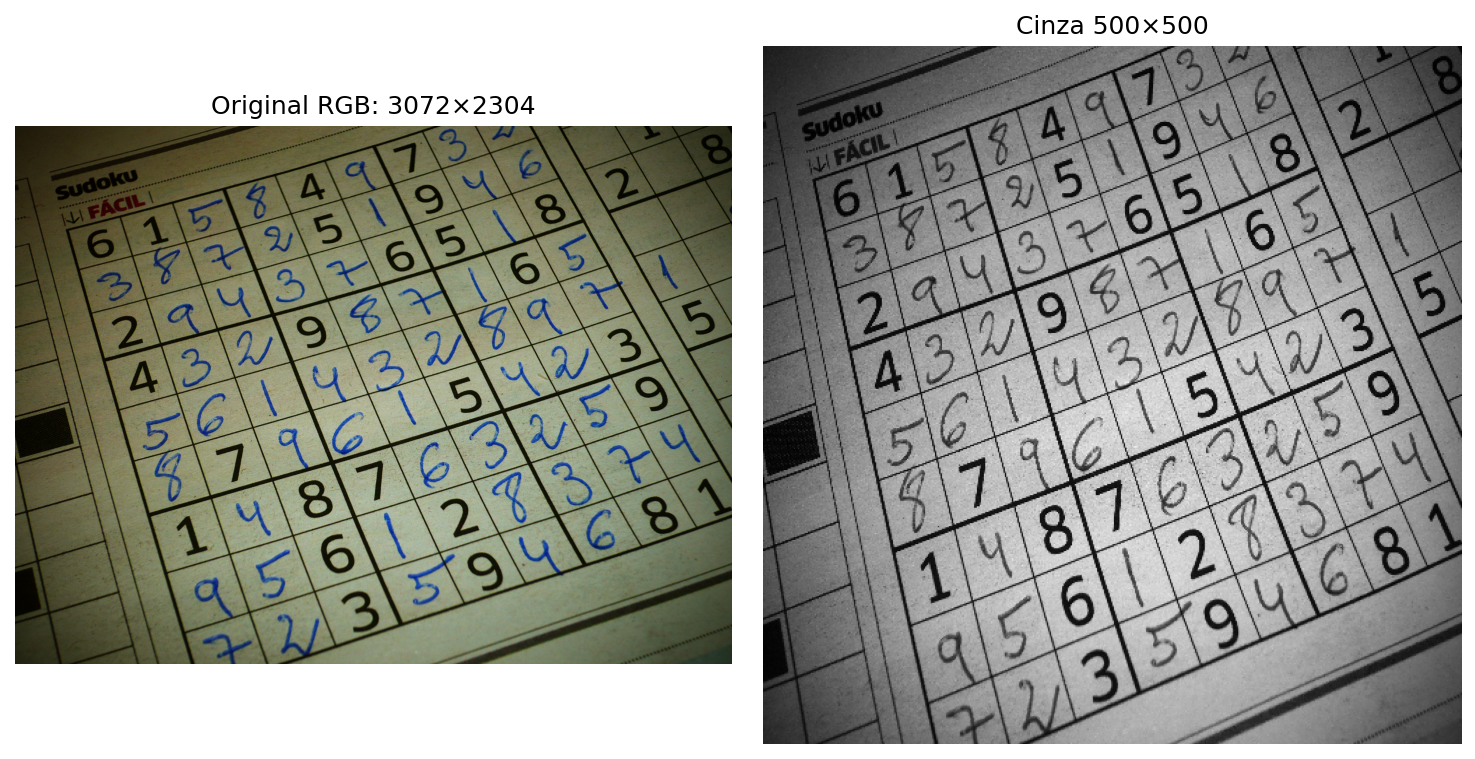

In [33]:
#[py]#
#| label: fig-02-sudoku-original
#| fig-cap: "Aquisição da imagem de um Sudoku à esquerda. À direita, conversão para tons de cinza e redimensionamento. Crédito: Héctor Rodríguez de Guardamar, Espanha (CC BY 2.0)."
#| echo: false
#| output: true

import numpy as np
import cv2

url = "https://upload.wikimedia.org/wikipedia/commons/e/e7/Sudoku_en_peri%C3%B3dico.jpg"
img_pil = mm.read(url, pil=True)
img_np  = np.array(img_pil)
img_gray  = mm.gray(img_np)
img_small = mm.resize(img_gray, (500, 500))
cv2.imwrite("sudoku.png", img_small)

mm.show(
    [img_np, img_small],
    titles=[
        f"Original RGB: {img_np.shape[1]}×{img_np.shape[0]}",
        "Cinza 500×500"
    ],
    cols=2
)

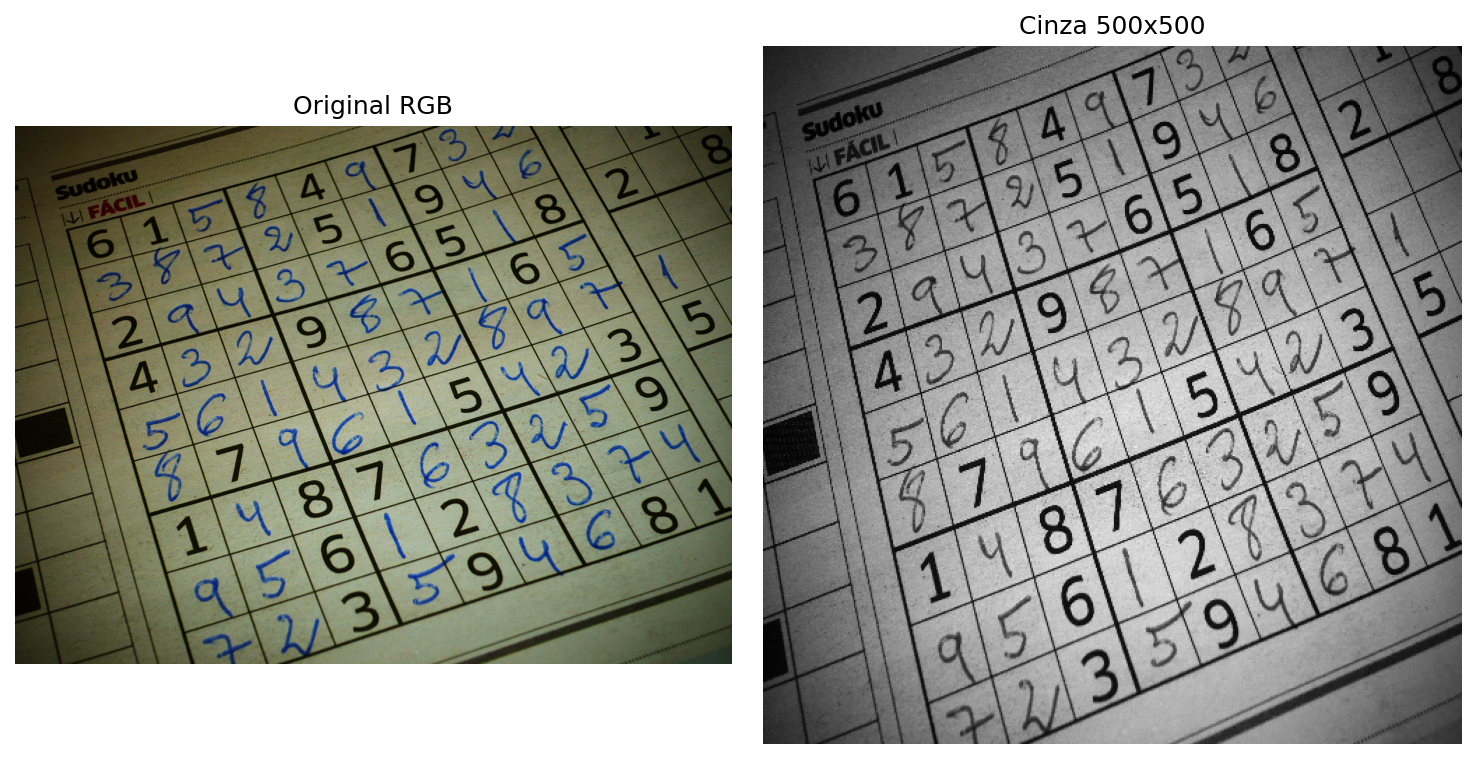

In [34]:
#[cpp]#
#| label: fig-02-sudoku-original
#| fig-cap: "Aquisição da imagem de um Sudoku à esquerda. À direita, conversão para tons de cinza e redimensionamento. Crédito: Héctor Rodríguez de Guardamar, Espanha (CC BY 2.0)."
#| echo: false
#| output: true

url = "https://upload.wikimedia.org/wikipedia/commons/e/e7/Sudoku_en_peri%C3%B3dico.jpg"
sudoku_rgb = mm.read(url)
sudoku_gray = mm.gray(sudoku_rgb)
sudoku_small = mm.resize(sudoku_gray, (500, 500))
mm.write(sudoku_small, "sudoku.png")   # consumida pela célula fig-02-sudoku2

mm.show(
    [sudoku_rgb, sudoku_small],
    titles=["Original RGB", "Cinza 500x500"],
    cols=2,
)


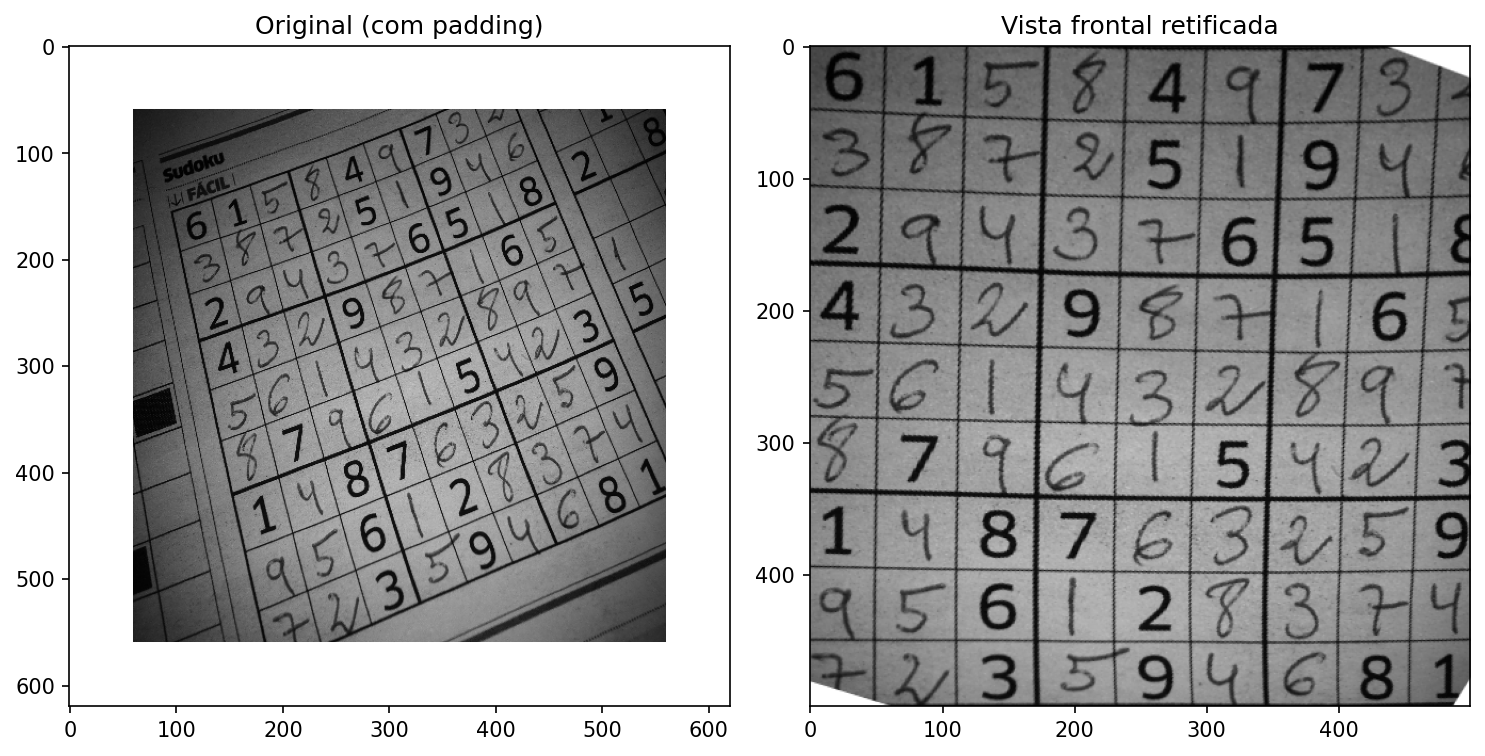

In [35]:
#[py]#
#| label: fig-02-sudoku2
#| fig-cap: "Correção de perspectiva: original e vista frontal retificada."
#| echo: true
#| output: true

import cv2
import numpy as np

# --- 1. Carrega a imagem salva (sudoku.png) ---
img = mm.read("sudoku.png")                # BGR, 500×500

# --- 2. Padding para não cortar vértices ---
PAD = 60
img_pad = cv2.copyMakeBorder(
    img, PAD, PAD, PAD, PAD,
    cv2.BORDER_CONSTANT, value=[255, 255, 255]
)

# --- 3. Pontos de origem (cantos da grade na imagem expandida) ---
pts1 = np.float32([
    [100, 160],    # TL
    [390, 45],    # TR
    [200, 580],   # BL
    [570, 420],   # BR
])
#     W    H

# --- 4. Pontos de destino (vista frontal 500×500) ---
SIZE = 500
pts2 = np.float32([
    [0,    0],
    [SIZE, 0],
    [0,    SIZE],
    [SIZE, SIZE],
])

# --- 5. Homografia e retificação ---
img_rect = mm.perspective_transform(img_pad, pts1, pts2, size=(SIZE, SIZE))

# --- 6. Exibição ---
mm.show(
    [img_pad, img_rect],
    titles=["Original (com padding)", "Vista frontal retificada"],
    cols=2, figsize=(10, 6), axis=True
)

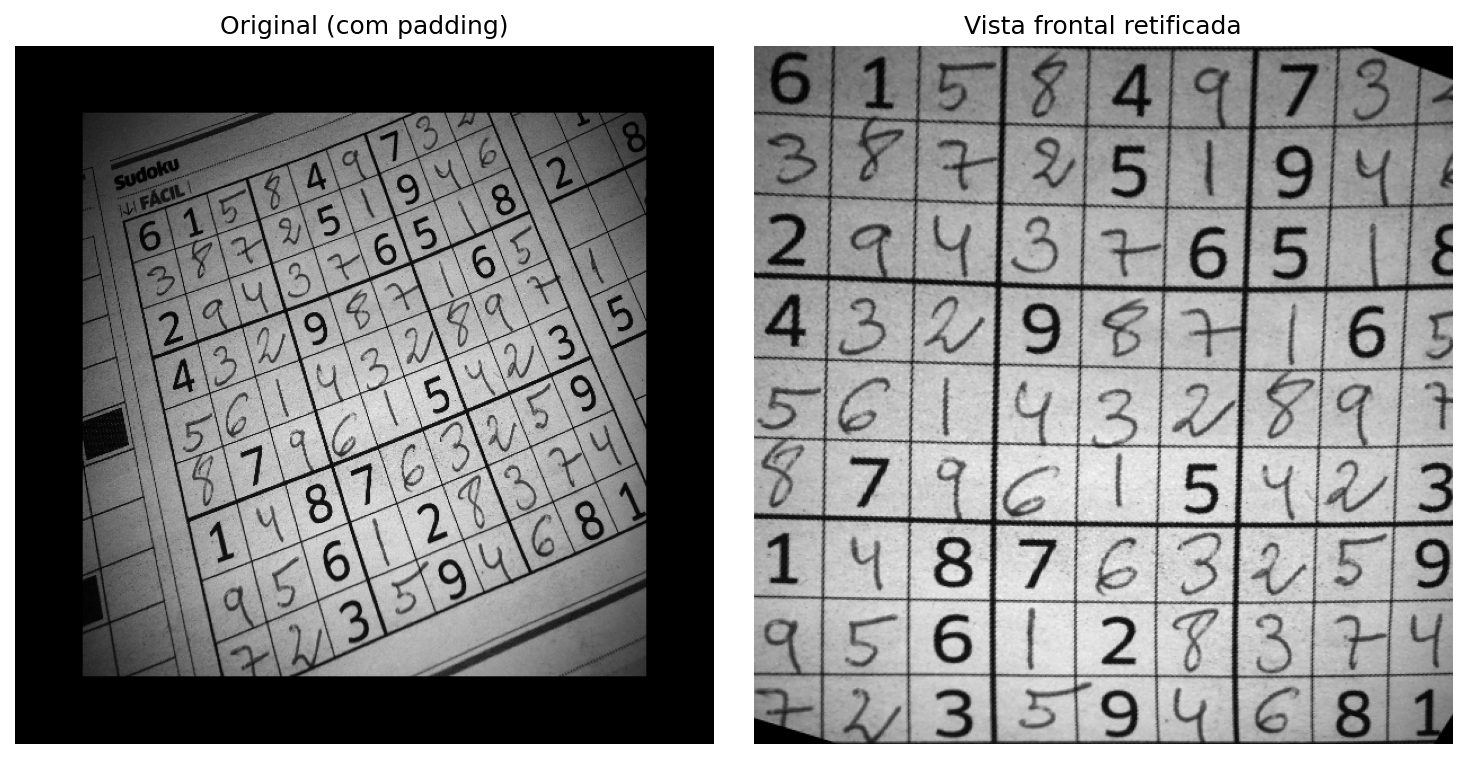

In [36]:
#[cpp]#
#| label: fig-02-sudoku2
#| fig-cap: "Correção de perspectiva por homografia 3×3: imagem com *padding* e a vista frontal retificada, via *mm::perspective_transform* (solve 8×8 dos 4 pontos + mapeamento inverso projetivo)."
#| echo: true
#| output: true

# 1. Imagem gravada pela célula anterior (sudoku.png, 500×500, cinza)
img = mm.read("sudoku.png")

# 2. Padding para não cortar os vértices da grade (mm::pad preenche com 0)
PAD = 60
img_pad = mm.pad(img, PAD)

# 3. Cantos da grade na imagem expandida — TL, TR, BL, BR
pts1 = [[100, 160], [390, 45], [200, 580], [570, 420]]

# 4. Cantos de destino: vista frontal SIZE×SIZE
SIZE = 500
pts2 = [[0, 0], [SIZE, 0], [0, SIZE], [SIZE, SIZE]]

# 5. Homografia pts1 -> pts2 e retificação
img_rect = mm.perspective_transform(img_pad, pts1, pts2, size=(SIZE, SIZE))

# 6. Exibição
mm.show(
    [img_pad, img_rect],
    titles=["Original (com padding)", "Vista frontal retificada"],
    cols=2,
)


In [37]:
#| label: fig-02-sim-ep0211-sudoku
#| fig-cap: "Simulador EP02_11: Correção de Perspectiva do Sudoku (Homografia 3×3 com Reamostragem Bilinear)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-ep0211-sudoku" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🎮 Simulador EP02_11: Perspectiva do Sudoku</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Homografia 3×3 · CC BY 2.0</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;justify-content:center;flex-wrap:wrap;margin-bottom:14px;">
      
      <!-- Canvas Origem -->
      <div style="text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#27ae60;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:6px;">📷 Original (Expandida) — Arraste os Cantos</span>
        <canvas id="sim_ep0211_canvas_src" width="400" height="400" style="border-radius:8px;border:2px solid #b9770e;background:#f1ead7;cursor:crosshair;display:block;margin:0 auto;"></canvas>
        <span style="font-size:9px;color:#8a8371;display:block;margin-top:4px;">Foto: Héctor Rodríguez · CC BY 2.0</span>
      </div>

      <!-- Canvas Destino -->
      <div style="text-align:center;">
        <span style="font-size:10px;font-weight:700;color:#2980b9;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:6px;">✅ Corrigida (400×400) — Visão Frontal</span>
        <canvas id="sim_ep0211_canvas_dst" width="400" height="400" style="border-radius:8px;border:2px solid #27ae60;background:#fafaf7;display:block;margin:0 auto;"></canvas>
      </div>

    </div>

    <!-- Botões de Ação -->
    <div style="display:flex;gap:8px;justify-content:center;margin-bottom:14px;flex-wrap:wrap;">
      <button id="sim_ep0211_btnReset" style="padding:5px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:16px;transition:all 0.15s ease;">↺ Redefinir Pontos</button>
      <button id="sim_ep0211_btnCorrect" style="padding:5px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:16px;font-family:monospace;transition:all 0.15s ease;">✨ Corrigir Perspectiva</button>
      <button id="sim_ep0211_btnPad" style="padding:5px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:16px;transition:all 0.15s ease;">🔲 Alternar Padding</button>
    </div>

    <!-- Painel Explicativo -->
    <div id="sim_ep0211_debug" style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:8px;padding:8px 12px;text-align:center;font-size:11px;font-family:monospace;color:#26241d;">
      Carregando imagem do Sudoku...
    </div>
  </div>
</div>

<script>
(function(){
  function initSimEP0211(root){
    if (!root || root.dataset.simEp0211Init) return;
    root.dataset.simEp0211Init = "1";

    var srcCanvas = root.querySelector('#sim_ep0211_canvas_src');
    var dstCanvas = root.querySelector('#sim_ep0211_canvas_dst');
    var ctxSrc    = srcCanvas.getContext('2d');
    var ctxDst    = dstCanvas.getContext('2d');

    var btnReset  = root.querySelector('#sim_ep0211_btnReset');
    var btnCorrect= root.querySelector('#sim_ep0211_btnCorrect');
    var btnPad    = root.querySelector('#sim_ep0211_btnPad');
    var debugDiv  = root.querySelector('#sim_ep0211_debug');

    var SIZE = 400;
    var PAD = 32;
    var img = null;
    var imgLoaded = false;
    var points = [];
    var dragIndex = -1;
    var showPad = false;

    function defaultPoints() {
      return [
        [PAD + 48, PAD + 38],        // TL
        [SIZE - PAD - 32, PAD + 28], // TR
        [PAD + 35, SIZE - PAD - 32], // BL
        [SIZE - PAD - 28, SIZE - PAD - 24] // BR
      ];
    }

    function loadImage() {
      var imageObj = new Image();
      imageObj.src = "sudoku.png";
      imageObj.crossOrigin = "Anonymous";

      imageObj.onload = function() {
        img = imageObj;
        imgLoaded = true;
        points = defaultPoints();
        drawSource();
        drawPlaceholder();
        debugDiv.innerHTML = "✅ Imagem local carregada! Arraste os marcadores nos cantos da grade.";
      };

      imageObj.onerror = function() {
        imageObj.src = "https://upload.wikimedia.org/wikipedia/commons/e/e7/Sudoku_en_peri%C3%B3dico.jpg";
        imageObj.onload = function() {
          img = imageObj;
          imgLoaded = true;
          points = defaultPoints();
          drawSource();
          drawPlaceholder();
          debugDiv.innerHTML = "⚠️ Imagem local não encontrada. Carregada imagem remota fallback.";
        };
        imageObj.onerror = function() {
          debugDiv.innerHTML = "❌ Erro ao carregar imagem. Verifique a existência de sudoku.png.";
          imgLoaded = false;
        };
      };
    }

    function drawSource() {
      if (!imgLoaded || !img) return;
      ctxSrc.clearRect(0, 0, SIZE, SIZE);
      ctxSrc.fillStyle = "#f1ead7";
      ctxSrc.fillRect(0, 0, SIZE, SIZE);

      var maxW = SIZE - 2 * PAD;
      var maxH = SIZE - 2 * PAD;
      var scale = Math.min(maxW / img.width, maxH / img.height);
      var drawW = img.width * scale;
      var drawH = img.height * scale;
      var offX = PAD + (maxW - drawW) / 2;
      var offY = PAD + (maxH - drawH) / 2;
      ctxSrc.drawImage(img, offX, offY, drawW, drawH);

      if (showPad) {
        ctxSrc.fillStyle = "rgba(41, 128, 185, 0.2)";
        ctxSrc.fillRect(0, 0, SIZE, PAD);
        ctxSrc.fillRect(0, SIZE - PAD, SIZE, PAD);
        ctxSrc.fillRect(0, 0, PAD, SIZE);
        ctxSrc.fillRect(SIZE - PAD, 0, PAD, SIZE);
        ctxSrc.strokeStyle = "#2980b9";
        ctxSrc.setLineDash([4, 6]);
        ctxSrc.strokeRect(PAD, PAD, SIZE - 2 * PAD, SIZE - 2 * PAD);
        ctxSrc.setLineDash([]);
      }

      if (points.length === 4) {
        ctxSrc.beginPath();
        ctxSrc.moveTo(points[0][0], points[0][1]);
        ctxSrc.lineTo(points[1][0], points[1][1]);
        ctxSrc.lineTo(points[3][0], points[3][1]);
        ctxSrc.lineTo(points[2][0], points[2][1]);
        ctxSrc.closePath();
        ctxSrc.strokeStyle = "#b9770e";
        ctxSrc.lineWidth = 2.5;
        ctxSrc.stroke();

        var labels = ["TL", "TR", "BL", "BR"];
        for (var i = 0; i < 4; i++) {
          ctxSrc.beginPath();
          ctxSrc.arc(points[i][0], points[i][1], 7, 0, 2 * Math.PI);
          ctxSrc.fillStyle = "#b9770e";
          ctxSrc.fill();
          ctxSrc.strokeStyle = "#ffffff";
          ctxSrc.lineWidth = 2;
          ctxSrc.stroke();

          ctxSrc.fillStyle = "#26241d";
          ctxSrc.font = "bold 11px monospace";
          var dx = (i === 0 || i === 2) ? -20 : 8;
          var dy = (i < 2) ? -8 : 14;
          ctxSrc.fillText(labels[i], points[i][0] + dx, points[i][1] + dy);
        }
      }
    }

    function drawPlaceholder() {
      ctxDst.clearRect(0, 0, SIZE, SIZE);
      ctxDst.fillStyle = "#fafaf7";
      ctxDst.fillRect(0, 0, SIZE, SIZE);
      ctxDst.fillStyle = "#8a8371";
      ctxDst.font = "11px monospace";
      ctxDst.textAlign = "center";
      ctxDst.fillText("Clique em 'Corrigir Perspectiva'", SIZE / 2, SIZE / 2 - 10);
      ctxDst.fillText("para retificar a grade do Sudoku", SIZE / 2, SIZE / 2 + 10);
      ctxDst.textAlign = "left";
    }

    function gaussSolve(A, b) {
      var n = A.length;
      var M = A.map(function(row, i) { return row.concat([b[i]]); });

      for (var i = 0; i < n; i++) {
        var maxRow = i;
        for (var k = i + 1; k < n; k++) {
          if (Math.abs(M[k][i]) > Math.abs(M[maxRow][i])) maxRow = k;
        }
        var temp = M[i]; M[i] = M[maxRow]; M[maxRow] = temp;

        if (Math.abs(M[i][i]) < 1e-8) return null;

        for (var k = i + 1; k <= n; k++) M[i][k] /= M[i][i];
        for (var k = 0; k < n; k++) {
          if (k !== i) {
            var factor = M[k][i];
            for (var j = i + 1; j <= n; j++) M[k][j] -= factor * M[i][j];
          }
        }
      }
      return M.map(function(row) { return row[n]; });
    }

    function getPerspectiveTransform(src, dst) {
      var A = [];
      for (var i = 0; i < 4; i++) {
        var x = src[i][0], y = src[i][1];
        var xp = dst[i][0], yp = dst[i][1];
        A.push([-x, -y, -1, 0, 0, 0, x * xp, y * xp, xp]);
        A.push([0, 0, 0, -x, -y, -1, x * yp, y * yp, yp]);
      }
      var B = [], C = [];
      for (var i = 0; i < 8; i++) {
        B.push(A[i].slice(0, 8));
        C.push(-A[i][8]);
      }
      var sol = gaussSolve(B, C);
      if (!sol) return null;
      var h = sol.concat([1]);
      return [[h[0], h[1], h[2]], [h[3], h[4], h[5]], [h[6], h[7], h[8]]];
    }

    function invertMatrix3x3(m) {
      var a = m[0][0], b = m[0][1], c = m[0][2];
      var d = m[1][0], e = m[1][1], f = m[1][2];
      var g = m[2][0], h = m[2][1], i = m[2][2];

      var det = a * (e * i - f * h) - b * (d * i - f * g) + c * (d * h - e * g);
      if (Math.abs(det) < 1e-8) return null;
      var invDet = 1 / det;

      return [
        [(e * i - f * h) * invDet, (c * h - b * i) * invDet, (b * f - c * e) * invDet],
        [(f * g - d * i) * invDet, (a * i - c * g) * invDet, (c * d - a * f) * invDet],
        [(d * h - e * g) * invDet, (b * g - a * h) * invDet, (a * e - b * d) * invDet]
      ];
    }

    function warpPerspective(sCanvas, dCanvas, H, outW, outH) {
      var sCtx = sCanvas.getContext('2d');
      var dCtx = dCanvas.getContext('2d');
      var srcImg = sCtx.getImageData(0, 0, sCanvas.width, sCanvas.height);
      var dstData = dCtx.createImageData(outW, outH);
      var srcData = srcImg.data;
      var srcW = sCanvas.width, srcH = sCanvas.height;
      var Hinv = invertMatrix3x3(H);
      if (!Hinv) return false;

      for (var y = 0; y < outH; y++) {
        for (var x = 0; x < outW; x++) {
          var denom = Hinv[2][0] * x + Hinv[2][1] * y + Hinv[2][2];
          if (Math.abs(denom) < 1e-6) continue;
          var u = (Hinv[0][0] * x + Hinv[0][1] * y + Hinv[0][2]) / denom;
          var v = (Hinv[1][0] * x + Hinv[1][1] * y + Hinv[1][2]) / denom;

          var idxDst = (y * outW + x) * 4;
          if (u >= 0 && u < srcW - 1 && v >= 0 && v < srcH - 1) {
            var x0 = Math.floor(u), y0 = Math.floor(v);
            var dx = u - x0, dy = v - y0;
            var idx = (y0 * srcW + x0) * 4;

            var c00 = [srcData[idx], srcData[idx + 1], srcData[idx + 2]];
            var c10 = [srcData[idx + 4], srcData[idx + 5], srcData[idx + 6]];
            var c01 = [srcData[idx + srcW * 4], srcData[idx + srcW * 4 + 1], srcData[idx + srcW * 4 + 2]];
            var c11 = [srcData[idx + srcW * 4 + 4], srcData[idx + srcW * 4 + 5], srcData[idx + srcW * 4 + 6]];

            var r = (1 - dx) * (1 - dy) * c00[0] + dx * (1 - dy) * c10[0] + (1 - dx) * dy * c01[0] + dx * dy * c11[0];
            var g = (1 - dx) * (1 - dy) * c00[1] + dx * (1 - dy) * c10[1] + (1 - dx) * dy * c01[1] + dx * dy * c11[1];
            var b = (1 - dx) * (1 - dy) * c00[2] + dx * (1 - dy) * c10[2] + (1 - dx) * dy * c01[2] + dx * dy * c11[2];

            dstData.data[idxDst]     = r;
            dstData.data[idxDst + 1] = g;
            dstData.data[idxDst + 2] = b;
            dstData.data[idxDst + 3] = 255;
          } else {
            dstData.data[idxDst]     = 241;
            dstData.data[idxDst + 1] = 234;
            dstData.data[idxDst + 2] = 215;
            dstData.data[idxDst + 3] = 255;
          }
        }
      }
      dCtx.putImageData(dstData, 0, 0);
      return true;
    }

    function correctPerspective() {
      if (!imgLoaded) { debugDiv.textContent = "Aguardando carregamento da imagem."; return; }
      var pts1 = points.map(function(p){ return [p[0], p[1]]; });
      var pts2 = [[0, 0], [SIZE, 0], [0, SIZE], [SIZE, SIZE]];
      var H = getPerspectiveTransform(pts1, pts2);

      if (!H) { debugDiv.textContent = "Erro: pontos colineares ou matriz singular."; return; }

      var tempCanvas = document.createElement('canvas');
      tempCanvas.width = SIZE;
      tempCanvas.height = SIZE;
      tempCanvas.getContext('2d').drawImage(srcCanvas, 0, 0);

      var success = warpPerspective(tempCanvas, dstCanvas, H, SIZE, SIZE);
      if (success) {
        debugDiv.innerHTML = '✅ <b>Homografia 3×3 aplicada:</b> Vértices retificados para grade frontal de ' + SIZE + '×' + SIZE + ' pixels.';
      } else {
        debugDiv.textContent = "❌ Falha na reamostragem de perspectiva.";
      }
    }

    function getMousePos(e, cEl) {
      var rect = cEl.getBoundingClientRect();
      var scaleX = cEl.width / rect.width;
      var scaleY = cEl.height / rect.height;
      var clientX = e.touches ? e.touches[0].clientX : e.clientX;
      var clientY = e.touches ? e.touches[0].clientY : e.clientY;
      return [(clientX - rect.left) * scaleX, (clientY - rect.top) * scaleY];
    }

    srcCanvas.addEventListener('mousedown', function(e) {
      var pos = getMousePos(e, srcCanvas);
      for (var i = 0; i < points.length; i++) {
        if (Math.sqrt(Math.pow(pos[0] - points[i][0], 2) + Math.pow(pos[1] - points[i][1], 2)) < 14) {
          dragIndex = i;
          srcCanvas.style.cursor = 'grabbing';
          break;
        }
      }
    });

    window.addEventListener('mousemove', function(e) {
      if (dragIndex === -1) return;
      var pos = getMousePos(e, srcCanvas);
      points[dragIndex] = [
        Math.min(SIZE - 5, Math.max(5, pos[0])),
        Math.min(SIZE - 5, Math.max(5, pos[1]))
      ];
      drawSource();
      debugDiv.textContent = 'Posicionando ponto ' + dragIndex + ' → (' + Math.round(points[dragIndex][0]) + ', ' + Math.round(points[dragIndex][1]) + ')';
    });

    window.addEventListener('mouseup', function() {
      dragIndex = -1;
      srcCanvas.style.cursor = 'crosshair';
    });

    btnReset.addEventListener('click', function() {
      points = defaultPoints();
      showPad = false;
      drawSource();
      drawPlaceholder();
      debugDiv.textContent = "Pontos redefinidos para as posições padrão.";
    });

    btnCorrect.addEventListener('click', correctPerspective);

    btnPad.addEventListener('click', function() {
      showPad = !showPad;
      drawSource();
    });

    loadImage();
  }

  function tryInitSimEP0211(){
    var root = document.getElementById('sim-ep0211-sudoku');
    if (root) initSimEP0211(root); else setTimeout(tryInitSimEP0211, 200);
  }
  tryInitSimEP0211();
})();
</script>
</div>
""")

In [38]:
%%writefile EP02_11.py
# Código Python

Overwriting EP02_11.py


In [39]:
TestSuite("EP02_11.py").run()